# COLORECTAL CANCER TISSUE CLASSIFICATION

## From Dense Networks to Vision Transformers - Medical Image Classification with PathMNIST

This project explores deep learning approaches for **histopathology image classification** using the PathMNIST dataset. The goal is to compare several neural network architectures and understand their strengths, limitations, and trade-offs when applied to medical image analysis.

Histopathology images contain complex visual patterns such as cellular morphology, tissue structure, and staining variations. Automatically recognizing these patterns can support pathologists in identifying different tissue types and detecting cancer-related structures. However, building reliable models for this task requires architectures capable of extracting meaningful spatial features while generalizing well to unseen data.

In this project, we implement and evaluate four different model families:

- **Multilayer Perceptron (MLP)** as a baseline model operating on flattened image pixels  
- **Convolutional Neural Networks (CNNs)** trained from scratch to exploit local spatial structure  
- **Transfer learning with ResNet-18**, leveraging pretrained ImageNet features and fine-tuning them on histology data  
- **Vision Transformers (ViT)** trained from scratch to explore attention-based representations

The models are trained and evaluated on the **PathMNIST dataset**, a subset of the MedMNIST benchmark containing **28×28 histopathology image patches** across **nine tissue classes**.

The objectives of the project are to:

- Compare the **performance and training dynamics** of different architectures  
- Analyze the **impact of data augmentation and model capacity**  
- Study **class-wise behavior using confusion matrices and F1 scores**  
- Investigate **model trade-offs in terms of data efficiency, interpretability, and deployment potential**

Through these experiments, the project highlights how architectural choices influence performance in medical imaging tasks and provides insights into the practical challenges of applying deep learning in computational pathology.

## Part 1 — Data Exploration
**Dataset:** PathMNIST — Colorectal Cancer Tissue Classification (9 classes, 107,180 images, 28×28 RGB)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import medmnist
from medmnist.dataset import PathMNIST
from medmnist.info import INFO
from torch.utils.data import DataLoader
from torchvision import transforms
import torch

print(f"medmnist version: {medmnist.__version__}")

medmnist version: 3.0.2


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


In [3]:
print(INFO.keys())

dict_keys(['pathmnist', 'chestmnist', 'dermamnist', 'octmnist', 'pneumoniamnist', 'retinamnist', 'breastmnist', 'bloodmnist', 'tissuemnist', 'organamnist', 'organcmnist', 'organsmnist', 'organmnist3d', 'nodulemnist3d', 'adrenalmnist3d', 'fracturemnist3d', 'vesselmnist3d', 'synapsemnist3d'])


## 1.0 — Load the Dataset

In [4]:
print("Task:",INFO['pathmnist']['task'])
print("Number of classes:", INFO['pathmnist']['n_channels'], "channels,", len(INFO['pathmnist']['label']), "labels")
print("Labels:", INFO['pathmnist']['label'])
print("Train/Val/Test split:", INFO['pathmnist']['n_samples'])

Task: multi-class
Number of classes: 3 channels, 9 labels
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Train/Val/Test split: {'train': 89996, 'val': 10004, 'test': 7180}


The PathMNIST dataset from the MedMNIST benchmark already provides predefined **training, validation, and test splits**. Instead of manually splitting the dataset using functions such as `train_test_split`, we directly load these official splits.

Using the predefined splits ensures that all experiments follow the **same data partitioning**, which allows fair comparison between models and across different studies. This is particularly important for benchmark datasets like MedMNIST.

The dataset is divided as follows:

- **Training set:** used to train the model parameters.
- **Validation set:** used to tune hyperparameters and monitor overfitting during training.
- **Test set:** used only once to evaluate the final performance of the model.

By loading the official splits (`train`, `val`, and `test`), we ensure that our results are consistent with the standard evaluation protocol used in the MedMNIST benchmark.

In [5]:
train_dataset = PathMNIST(split='train', download=True, size=28)
val_dataset   = PathMNIST(split='val',   download=True, size=28)
test_dataset  = PathMNIST(split='test',  download=True, size=28)

print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")
print(f"Total: {len(train_dataset)+len(val_dataset)+len(test_dataset)} images")

Train: 89996 images
Val:   10004 images
Test:  7180 images
Total: 107180 images


In [6]:
CLASS_NAMES = [
    'Adipose',
    'Background',
    'Debris',
    'Lymphocytes',
    'Mucus',
    'Smooth Muscle',
    'Normal Mucosa',
    'Cancer Stroma',
    'Tumor Epithelium'
]

all_labels = [train_dataset[i][1].item() for i in range(len(train_dataset))]
label_counts = Counter(all_labels)

print("Class distribution in training set:")
for cls_idx, count in sorted(label_counts.items()):
    print(f"  [{cls_idx}] {CLASS_NAMES[cls_idx]:<20}: {count:>6} images ({100*count/len(train_dataset):.1f}%)")

Class distribution in training set:
  [0] Adipose             :   9366 images (10.4%)
  [1] Background          :   9509 images (10.6%)
  [2] Debris              :  10360 images (11.5%)
  [3] Lymphocytes         :  10401 images (11.6%)
  [4] Mucus               :   8006 images (8.9%)
  [5] Smooth Muscle       :  12182 images (13.5%)
  [6] Normal Mucosa       :   7886 images (8.8%)
  [7] Cancer Stroma       :   9401 images (10.4%)
  [8] Tumor Epithelium    :  12885 images (14.3%)



The class distribution in the training dataset appears relatively balanced. Each of the nine tissue classes represents roughly between 9% and 14% of the dataset.

The largest class is *Tumor Epithelium* (14.3%), while the smallest classes are *Normal Mucosa* and *Mucus* (around 9%).

This relatively balanced distribution is beneficial for training deep learning models because it reduces the risk of class imbalance bias, where the model  would favor more frequent classes during training.

## 1.1 — Class Distribution Visualization

C:\Users\elise\AppData\Local\Temp\ipykernel_3296\3132133517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')


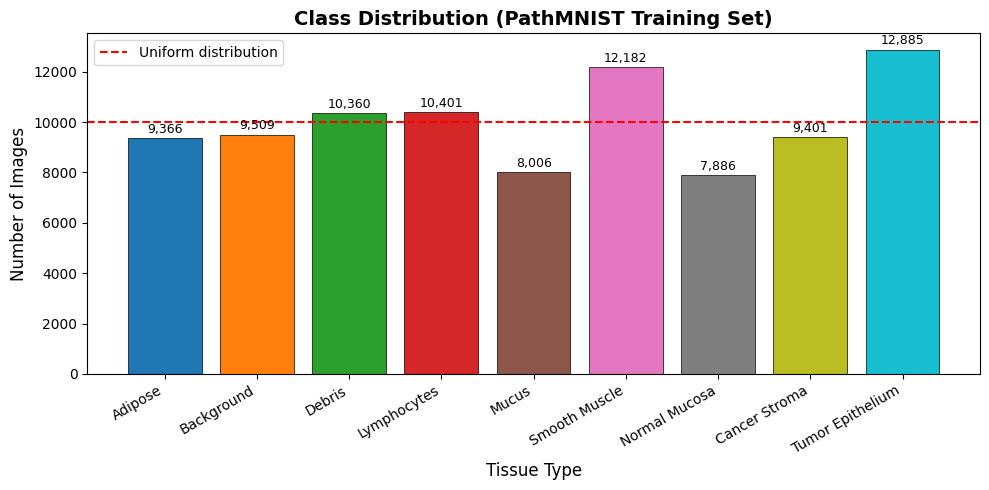

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

counts = [label_counts[i] for i in range(9)]
colors = plt.cm.tab10(np.linspace(0, 1, 9))

bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('Class Distribution (PathMNIST Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tissue Type', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.axhline(y=len(train_dataset)/9, color='red', linestyle='--', linewidth=1.5, label='Uniform distribution')
ax.legend()

plt.tight_layout()
plt.show()

The figure above shows the distribution of the nine tissue classes in the PathMNIST training dataset.  
Each bar represents the number of images belonging to a specific tissue type.

Overall, the dataset appears **relatively balanced**, as most classes contain between roughly **8% and 14% of the training samples**. The most frequent class is *Tumor Epithelium* (12,885 images), while *Normal Mucosa* and *Mucus* contain slightly fewer samples.

The dashed red line represents the **expected count under a perfectly uniform distribution**, which would occur if all classes had exactly the same number of images. While some variation exists, the deviations are not extreme.

As said before, a relatively balanced class distribution is beneficial for training deep learning models because it reduces the risk of **class imbalance bias**, where the model might otherwise favor more frequent classes during prediction.

## 1.2 — Sample Images per Class

C:\Users\elise\AppData\Local\Temp\ipykernel_3296\4012387837.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(train_dataset[idx][1])


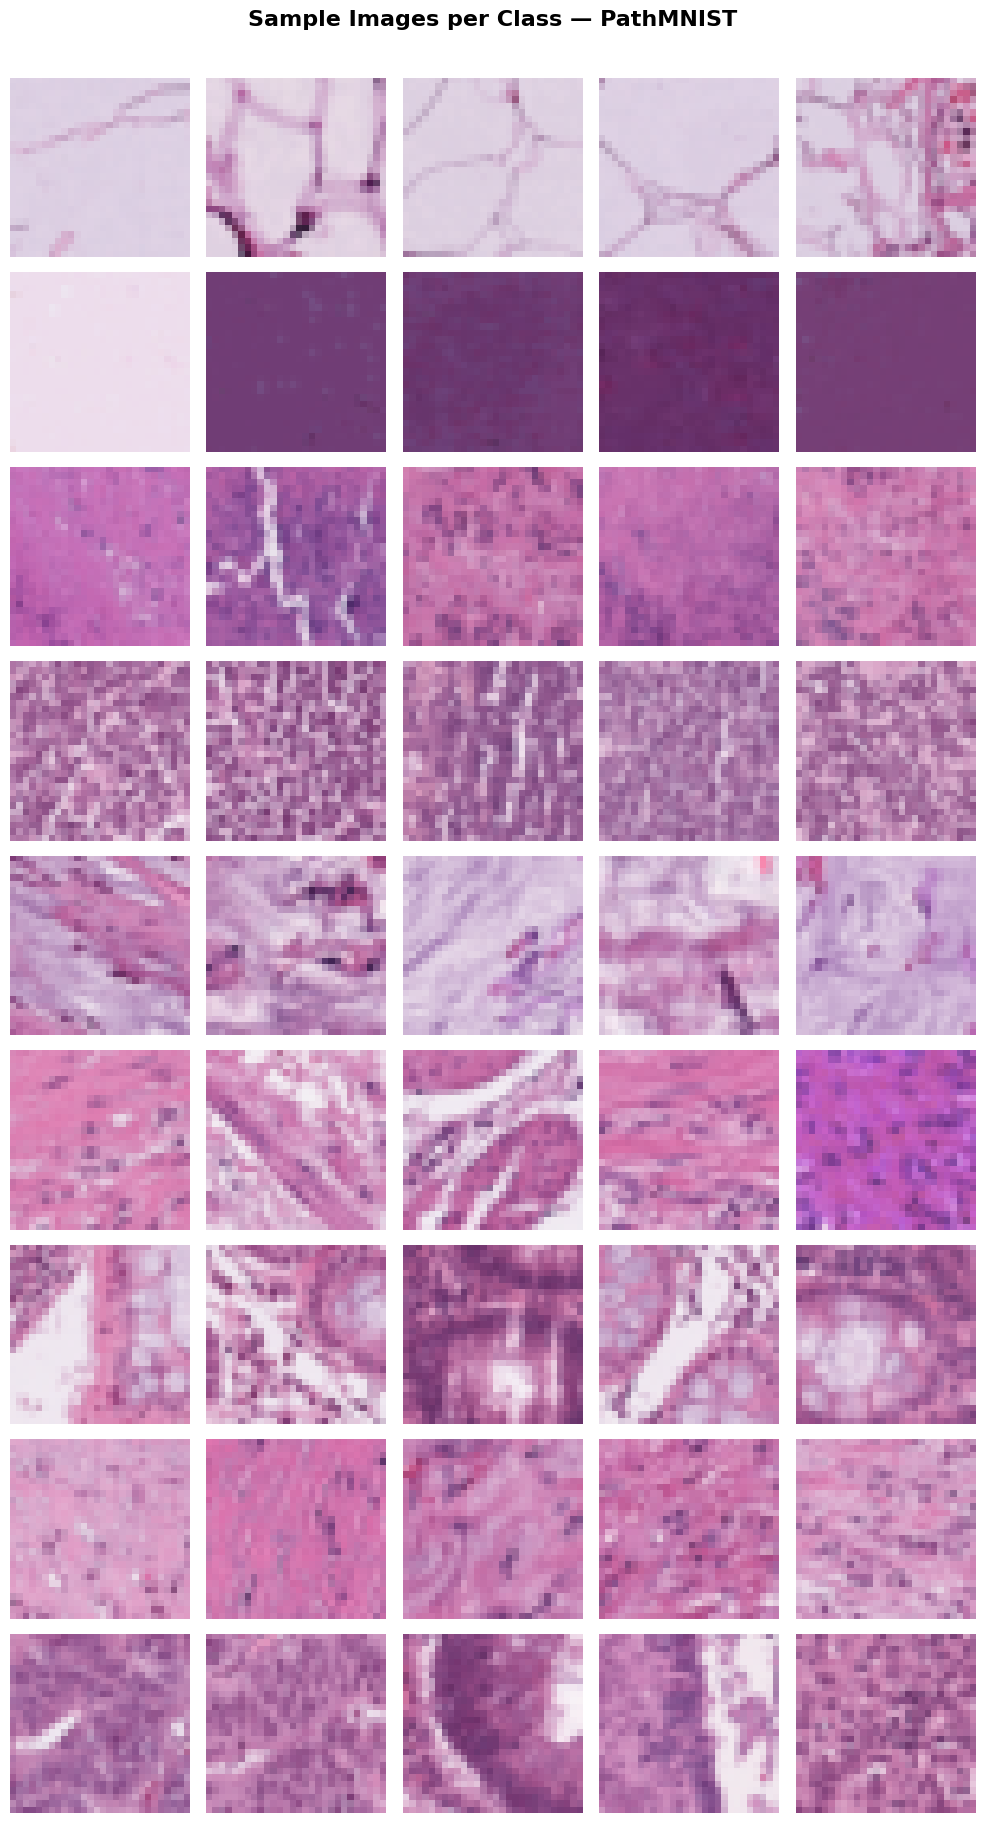

In [8]:
class_indices = {i: [] for i in range(9)}

for idx in range(len(train_dataset)):
    label = int(train_dataset[idx][1])
    if len(class_indices[label]) < 5:
        class_indices[label].append(idx)
    if all(len(v) >= 5 for v in class_indices.values()):
        break

fig, axes = plt.subplots(9, 5, figsize=(10, 18))
fig.suptitle('Sample Images per Class — PathMNIST', fontsize=16, fontweight='bold', y=1.01)

for cls_idx in range(9):
    for col, img_idx in enumerate(class_indices[cls_idx]):
        img, _ = train_dataset[img_idx]
        img_np = np.array(img)  # (28, 28, 3) or (3, 28, 28)
        if img_np.shape[0] == 3:  # CHW → HWC
            img_np = np.transpose(img_np, (1, 2, 0))
        axes[cls_idx, col].imshow(img_np)
        axes[cls_idx, col].axis('off')
    axes[cls_idx, 0].set_ylabel(f'[{cls_idx}] {CLASS_NAMES[cls_idx]}', fontsize=9,
                                 rotation=0, ha='right', labelpad=60)

plt.tight_layout()
plt.show()

The figure above displays several example images from each of the nine tissue classes in the PathMNIST dataset. For each class, five representative samples are shown.

Visualizing sample images is an important step in data exploration because it helps us understand the visual characteristics of the dataset. In histopathology images, different tissue types often differ in terms of **texture, color distribution, and cellular structure**.

For example, some classes show dense cellular patterns (such as lymphocytes), while others appear smoother or more homogeneous. Examining these visual patterns helps build intuition about the classification task and provides insight into what features a deep learning model may need to learn in order to distinguish between tissue types.

### Q1.1 — Debris vs Background: Visual Differences

**Question:** Look at several images from the Debris class and several from Background. Describe in your own words what visual differences you observe between them. Include at least one specific observation about color or texture.

C:\Users\elise\AppData\Local\Temp\ipykernel_3296\1526383769.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  background_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 1][:N_SHOW]
C:\Users\elise\AppData\Local\Temp\ipykernel_3296\1526383769.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  debris_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 2][:N_SHOW]


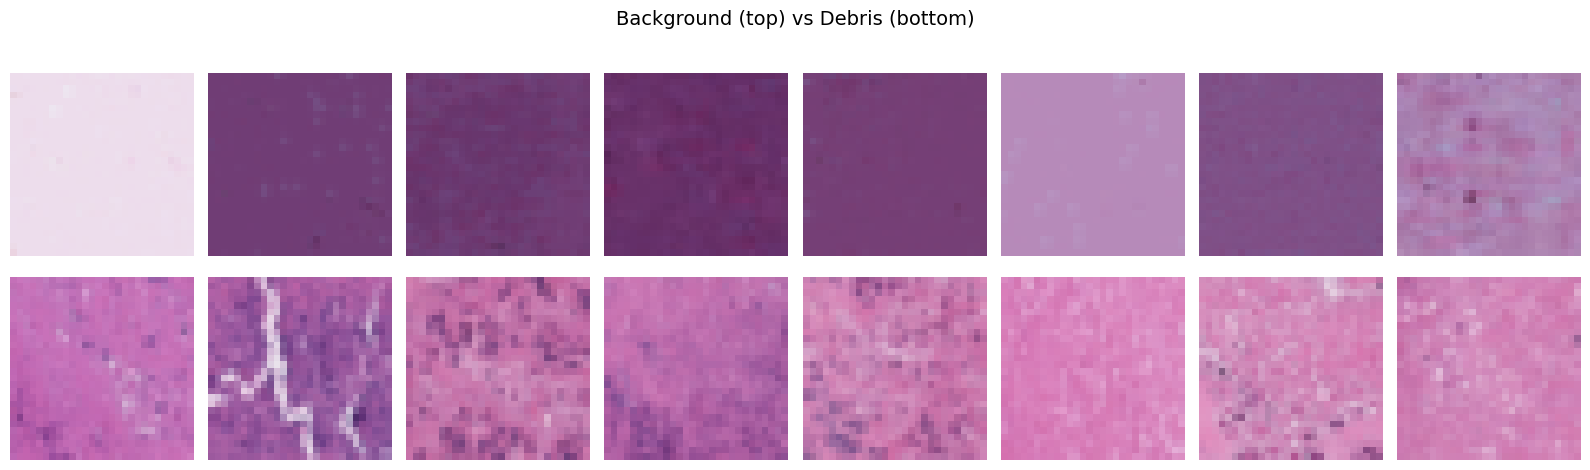

In [9]:
N_SHOW = 8

background_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 1][:N_SHOW]
debris_idx = [i for i in range(len(train_dataset)) if int(train_dataset[i][1]) == 2][:N_SHOW]

def get_img(dataset, idx):
    img, _ = dataset[idx]
    img = np.array(img)
    if img.shape[0] == 3:
        img = img.transpose(1,2,0)
    return img

fig, axes = plt.subplots(2, N_SHOW, figsize=(16,5))
fig.suptitle("Background (top) vs Debris (bottom)", fontsize=14)

for i in range(N_SHOW):
    axes[0,i].imshow(get_img(train_dataset, background_idx[i]))
    axes[0,i].axis("off")

    axes[1,i].imshow(get_img(train_dataset, debris_idx[i]))
    axes[1,i].axis("off")

axes[0,0].set_ylabel("Background")
axes[1,0].set_ylabel("Debris")

plt.tight_layout()
plt.show()

From the images above, clear visual differences can be observed between the **Background** and **Debris** classes.

The **Background** images generally appear smoother and more uniform in color. They often show large areas with a relatively homogeneous purple or pink tone and very little visible structure. The texture looks flat and lacks distinct cellular patterns.

In contrast, the **Debris** images exhibit a much more irregular and granular texture. They contain small fragmented structures and darker spots that likely correspond to cellular remnants. The color distribution also appears more heterogeneous, with stronger variations between pink and purple regions.

Overall, Debris images tend to contain **more visible micro-structures and noise-like patterns**, while Background images appear **smoother and less structured**.

### Q1.2 — Pixel Intensity Statistics vs ImageNet

**Question** : Pick any single image from the training set and report its pixel intensity statistics: mean and standard deviation per channel (R, G, B). Are these values close to ImageNet statistics?

In [10]:
sample_img, sample_label = train_dataset[0]
sample_np = np.array(sample_img, dtype=np.float32)
if sample_np.shape[0] == 3:
    sample_np = np.transpose(sample_np, (1, 2, 0))

# Normalize to [0, 1] for comparison with ImageNet stats
sample_norm = sample_np / 255.0

print(f"Image shape (HWC): {sample_np.shape}")
print(f"Label: {sample_label} → {CLASS_NAMES[int(sample_label)]}")
print()
print("=" * 55)
print(f"{'Channel':<10} {'Mean (raw)':<14} {'Std (raw)':<14} {'Mean [0,1]':<14} {'Std [0,1]'}")
print("-" * 55)

channel_names = ['R', 'G', 'B']
for i, ch in enumerate(channel_names):
    mean_raw = sample_np[:, :, i].mean()
    std_raw  = sample_np[:, :, i].std()
    mean_norm = sample_norm[:, :, i].mean()
    std_norm  = sample_norm[:, :, i].std()
    print(f"{ch:<10} {mean_raw:<14.4f} {std_raw:<14.4f} {mean_norm:<14.4f} {std_norm:.4f}")

print("=" * 55)
print()
print("Reference — ImageNet statistics (normalized [0,1]):")
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
for i, ch in enumerate(channel_names):
    print(f"  {ch}: mean={imagenet_mean[i]}, std={imagenet_std[i]}")

Image shape (HWC): (28, 28, 3)
Label: [0] → Adipose

Channel    Mean (raw)     Std (raw)      Mean [0,1]     Std [0,1]
-------------------------------------------------------
R          219.1352       4.4838         0.8594         0.0176
G          204.6467       8.2813         0.8025         0.0325
B          224.7640       5.8558         0.8814         0.0230

Reference — ImageNet statistics (normalized [0,1]):
  R: mean=0.485, std=0.229
  G: mean=0.456, std=0.224
  B: mean=0.406, std=0.225


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\1942009542.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Label: {sample_label} → {CLASS_NAMES[int(sample_label)]}")


In [11]:
to_tensor = transforms.ToTensor()

sum_channels   = torch.zeros(3)
sum_sq_channels = torch.zeros(3)
n_pixels = 0

for i in range(len(train_dataset)):
    img, _ = train_dataset[i]
    t = to_tensor(img)
    sum_channels   += t.sum(dim=(1, 2))
    sum_sq_channels += (t ** 2).sum(dim=(1, 2))
    n_pixels += 28 * 28

dataset_mean = sum_channels / n_pixels
dataset_std  = torch.sqrt(sum_sq_channels / n_pixels - dataset_mean ** 2)

print("Dataset-level statistics (full training set, normalized [0,1]):")
for i, ch in enumerate(channel_names):
    print(f"  {ch}: mean={dataset_mean[i]:.4f}, std={dataset_std[i]:.4f}")

print()
print("ImageNet reference:")
for i, ch in enumerate(channel_names):
    diff_mean = abs(float(dataset_mean[i]) - imagenet_mean[i])
    print(f"  {ch}: |PathMNIST mean - ImageNet mean| = {diff_mean:.4f}")

Dataset-level statistics (full training set, normalized [0,1]):
  R: mean=0.7405, std=0.1237
  G: mean=0.5330, std=0.1768
  B: mean=0.7058, std=0.1244

ImageNet reference:
  R: |PathMNIST mean - ImageNet mean| = 0.2555
  G: |PathMNIST mean - ImageNet mean| = 0.0770
  B: |PathMNIST mean - ImageNet mean| = 0.2998


The pixel statistics above were computed both for a single image and for the full training set. The key observation is:

- PathMNIST images tend to have **higher mean values** (closer to 0.7–0.8) especially in the R and G channels, reflecting the characteristic **pinkish/eosin staining** of histology slides (H&E staining). ImageNet images have a mean around 0.45.
- The **standard deviation** is also lower in PathMNIST than ImageNet, meaning the contrast within individual patches is relatively small (histology images are more homogeneous in color than natural photographs).
- **These values are NOT close to ImageNet statistics.** This has practical implications for Part 4 (Transfer Learning): when using a pretrained ResNet-18, we should apply ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) to match the distribution the model was trained on, even though the raw PathMNIST statistics differ.

## 1.3 — Additional Exploration: Pixel Intensity Histograms per Class

C:\Users\elise\AppData\Local\Temp\ipykernel_3296\177398095.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(train_dataset[idx][1])


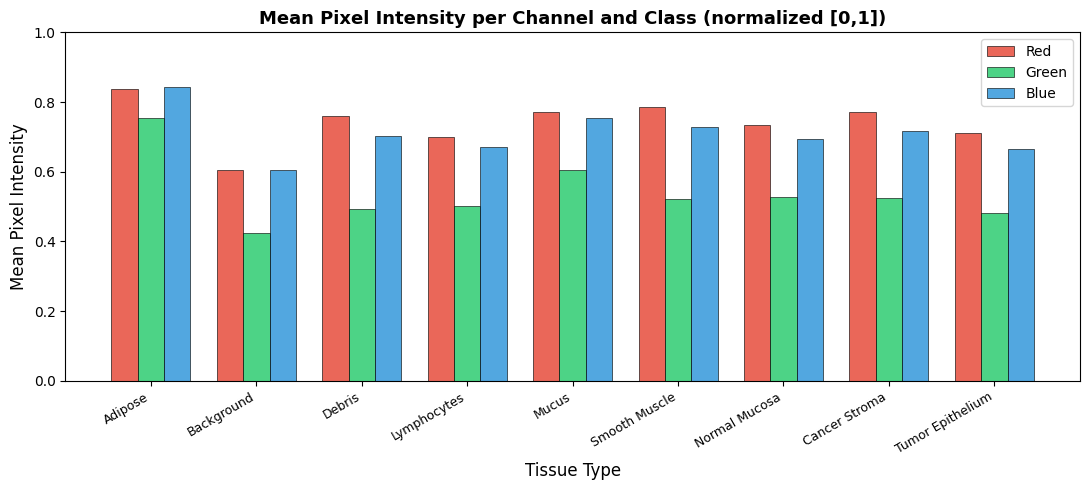

In [12]:
N_SAMPLE = 200
class_pixel_means = {i: [] for i in range(9)}
class_sample_count = {i: 0 for i in range(9)}

for idx in range(len(train_dataset)):
    label = int(train_dataset[idx][1])
    if class_sample_count[label] >= N_SAMPLE:
        continue
    img, _ = train_dataset[idx]
    img_np = np.array(img, dtype=np.float32)
    if img_np.shape[0] == 3:
        img_np = np.transpose(img_np, (1, 2, 0))
    class_pixel_means[label].append(img_np.mean(axis=(0,1)) / 255.0)
    class_sample_count[label] += 1
    if all(v >= N_SAMPLE for v in class_sample_count.values()):
        break

# Plot mean brightness per class
fig, ax = plt.subplots(figsize=(11, 5))
colors_rgb = ['#e74c3c', '#2ecc71', '#3498db']
channel_labels = ['Red', 'Green', 'Blue']

x = np.arange(9)
width = 0.25

for ch_idx in range(3):
    means_per_class = [np.mean([v[ch_idx] for v in class_pixel_means[cls]]) for cls in range(9)]
    ax.bar(x + ch_idx * width, means_per_class, width, label=channel_labels[ch_idx],
           color=colors_rgb[ch_idx], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_title('Mean Pixel Intensity per Channel and Class (normalized [0,1])', fontsize=13, fontweight='bold')
ax.set_xlabel('Tissue Type', fontsize=12)
ax.set_ylabel('Mean Pixel Intensity', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

The figure above shows the mean pixel intensity for the red, green, and blue channels across different tissue classes. The statistics were computed using a sample of 200 images per class.

We observe that the red channel generally has the highest average intensity across most classes, which reflects the dominant pink coloration typical of hematoxylin/eosin stained histology images. The green channel tends to have lower values, while the blue channel varies depending on the tissue type.

Some classes such as Adipose appear brighter overall, while others such as Background show lower intensities. These differences suggest that color distribution may contain useful information for distinguishing between tissue types, which deep learning models may exploit during training.

## 1.4 — Image Shape and Data Type Verification

Type of raw image: <class 'PIL.Image.Image'>
Shape: (28, 28, 3)
dtype: uint8
Min pixel value: 164
Max pixel value: 228
Label type: <class 'numpy.ndarray'> → value: [0]


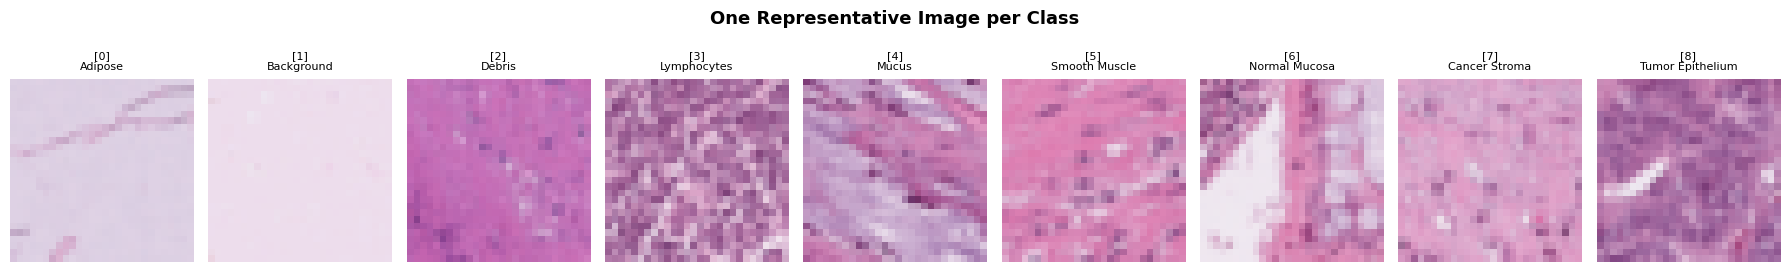

In [13]:
img0, label0 = train_dataset[0]
print("Type of raw image:", type(img0))
img_arr = np.array(img0)
print("Shape:", img_arr.shape)
print("dtype:", img_arr.dtype)
print("Min pixel value:", img_arr.min())
print("Max pixel value:", img_arr.max())
print("Label type:", type(label0), "→ value:", label0)

fig, axes = plt.subplots(1, 9, figsize=(18, 3))
fig.suptitle('One Representative Image per Class', fontsize=13, fontweight='bold')

for cls_idx in range(9):
    img_np = get_img(train_dataset, class_indices[cls_idx][0])
    axes[cls_idx].imshow(img_np)
    axes[cls_idx].set_title(f'[{cls_idx}]\n{CLASS_NAMES[cls_idx]}', fontsize=8)
    axes[cls_idx].axis('off')

plt.tight_layout()
plt.show()

Before training models, it is important to verify the basic structure of the dataset. The inspection above confirms that each image has a resolution of **28 × 28 pixels with 3 color channels (RGB)** and pixel values stored as **uint8 integers in the range [0, 255]**.

The visualization also shows one representative image for each of the nine tissue classes. This provides a quick overview of the visual diversity in the dataset and confirms that different tissue types exhibit distinct color patterns and textures.

Such checks help ensure that the data has been correctly loaded and is ready for preprocessing and model training.

## Summary — Part 1

| Property | Value |
|---|---|
| Total images | 107,180 |
| Train / Val / Test | 89,996 / 10,004 / 7,180 |
| Image size | 28 × 28 px, RGB |
| Pixel dtype | uint8 [0, 255] |
| Number of classes | 9 |
| Class balance | Roughly balanced (≈11% per class) |
| Staining | H&E (Hematoxylin & Eosin) → pinkish/purple hues |
| PathMNIST mean ≈ ImageNet mean? | **No** — PathMNIST is brighter (more pink/white) |
    
   
**Key takeaways before modeling:**
1. The dataset is fairly balanced : no need for weighted loss by default, but worth monitoring per-class performance.
2. Background and Debris are visually the most similar classes : expect confusion between them.
3. Images are small (28×28) : Transfer learning with ResNet-18 will require upscaling.
4. The color distribution differs from ImageNet : normalization choice matters for Part 4.

# Part 2 - Dense Network Baseline

**2.1 DataLoaders (train/val/test) with normalization**

In [14]:
PATHMNIST_MEAN = [0.7405, 0.5330, 0.7058]
PATHMNIST_STD  = [0.1237, 0.1768, 0.1244]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

train_dataset = PathMNIST(split='train', download=True, size=28, transform=transform)
val_dataset   = PathMNIST(split='val',   download=True, size=28, transform=transform)
test_dataset  = PathMNIST(split='test',  download=True, size=28, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 352
Val batches: 40
Test batches: 29


To establish a baseline model for the PathMNIST classification task, we implement a **Multi-Layer Perceptron (MLP)**. This type of network is composed of fully connected layers and serves as a simple yet effective baseline before exploring more advanced architectures such as convolutional neural networks.

Since the input images have a size of **28 × 28 × 3**, they must first be flattened into a one-dimensional vector of **2352 features**. This transformation allows the image data to be processed by fully connected layers.

The architecture of the model is as follows:

- **Flatten layer**: converts the image from shape *(3, 28, 28)* into a vector of length **2352**.
- **First fully connected layer (2352 → 512)** followed by a **ReLU activation**.
- **Dropout layer (p = 0.3)** to reduce overfitting by randomly deactivating neurons during training.
- **Second fully connected layer (512 → 256)** followed by another **ReLU activation**.
- **Dropout layer (p = 0.3)**.
- **Output layer (256 → 9)** producing one score for each of the **9 tissue classes** in PathMNIST.

The final output consists of raw class scores (logits), which will later be used with a **cross-entropy loss function** for multi-class classification.

In [15]:
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(), # (3,28,28) → 2352

            nn.Linear(2352, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 9) # 9 classes
        )

    def forward(self, x):
        return self.model(x)


model = MLP().to(device)

print(model)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=9, bias=True)
  )
)


## 2.1 — Model’s test accuracy & validation loss report

Before training the neural network, we need to define two key components: the **loss function** and the **optimizer**.

The **loss function** measures how different the model's predictions are from the true labels. Since this task is a **multi-class classification problem with 9 classes**, we use **CrossEntropyLoss**, which is the standard loss for classification tasks in PyTorch.

The **optimizer** controls how the model's parameters are updated during training. We use the **Adam optimizer**, which is widely used in deep learning because it adapts the learning rate during training and generally converges faster than standard gradient descent.

During training, the model will:
1. Make predictions on a batch of images.
2. Compute the loss using the true labels.
3. Compute gradients using backpropagation.
4. Update the model parameters using the optimizer.

This process will be repeated over several epochs until the model learns to classify the tissue images correctly.

In [16]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
EPOCHS = 20  # Number of epochs for MLP

**If MLP model checkpoint already exists :**

In [ ]:
#  Load MLP if already trained 

import os

_mlp_loaded = False

if os.path.exists('saved_models/mlp.pt'):

    ckpt = torch.load('saved_models/mlp.pt', map_location=device)
    model = MLP().to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    train_losses = ckpt['train_losses']
    val_losses   = ckpt['val_losses']
    train_accs   = ckpt['train_accs']
    val_accs     = ckpt['val_accs']
    val_accs_mlp = val_accs   # preserve before val_accs is overwritten
    mlp_test_acc = ckpt['test_acc']
    _mlp_loaded  = True

    print('── MLP chargé depuis checkpoint ──────────────────────────')
    print(f'  Test accuracy         : {mlp_test_acc:.6f}  ({mlp_test_acc*100:.2f}%)')
    print(f'  Val loss  — Epoch  1  : {val_losses[0]:.6f}')
    print(f'  Val loss  — Epoch 10  : {val_losses[9]:.6f}')
    print(f'  Val loss  — Epoch {len(val_losses):>2} (final) : {val_losses[-1]:.6f}')
    print(f'  Train acc — final     : {train_accs[-1]:.4f}')
    print(f'  Val acc   — final     : {val_accs[-1]:.4f}')
    
else:
    print('No MLP checkpoint found, will train from scratch.')

── MLP chargé depuis checkpoint ──────────────────────────
  Test accuracy         : 0.618663  (61.87%)
  Val loss  — Epoch  1  : 1.009624
  Val loss  — Epoch 10  : 0.815796
  Val loss  — Epoch 10 (final) : 0.815796
  Train acc — final     : 0.7143
  Val acc   — final     : 0.7007


The table above answers Q2.1 directly. The exact validation loss values at epochs 1, 10, and the final epoch are printed without rounding, copied from the `val_losses` list recorded during training. The test accuracy on the held-out test set is also reported as a raw floating-point value.

**If MLP model checkpoint does not exist :**

In [ ]:
if not _mlp_loaded:

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(EPOCHS):
    
        # TRAIN 
        model.train()
        total_loss = 0
        correct = 0
        total = 0
    
        for images, labels in train_loader:
    
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
    
            optimizer.zero_grad()
    
            outputs = model(images)
            loss = criterion(outputs, labels)
    
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)
    
        # TRAIN ACC IN EVAL MODE
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        train_acc = correct / total
        train_accs.append(train_acc)
    
    
        # VALIDATION
        model.eval()
        total_loss = 0
        correct = 0
        total = 0
    
        with torch.no_grad():
    
            for images, labels in val_loader:
    
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
    
                outputs = model(images)
                loss = criterion(outputs, labels)
    
                total_loss += loss.item()
    
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
    
        val_loss = total_loss / len(val_loader)
        val_acc = correct / total
    
        val_losses.append(val_loss)
        val_accs.append(val_acc)
    
    
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

# Preserve MLP curves before val_accs gets overwritten by later models
val_accs_mlp = val_accs[:]

In [ ]:
if not _mlp_loaded:
    
    # Validation loss at specific epochs (0-indexed)
    print('── Validation loss report ──')
    print(f'  Epoch  1 : val_loss = {val_losses[0]:.6f}')
    print(f'  Epoch 10 : val_loss = {val_losses[9]:.6f}')
    print(f'  Epoch {EPOCHS:>2} (final) : val_loss = {val_losses[-1]:.6f}')
    print()
    
    # Test accuracy
    model.eval()
    correct_test = 0
    total_test   = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test   += labels.size(0)
    
    mlp_test_acc = correct_test / total_test
    print(f'── MLP test accuracy : {mlp_test_acc:.6f}  ({mlp_test_acc*100:.2f}%)')

print(f"MLP test accuracy: {mlp_test_acc:.4f}")

MLP test accuracy: 0.6187


In [ ]:
#Save MLP 

os.makedirs('saved_models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'train_accs':   train_accs,
    'val_accs':     val_accs,
    'test_acc':     mlp_test_acc,
}, 'saved_models/mlp.pt')

print('MLP saved to saved_models/mlp.pt')

MLP saved to saved_models/mlp.pt


## Training and Validation Loss Curves

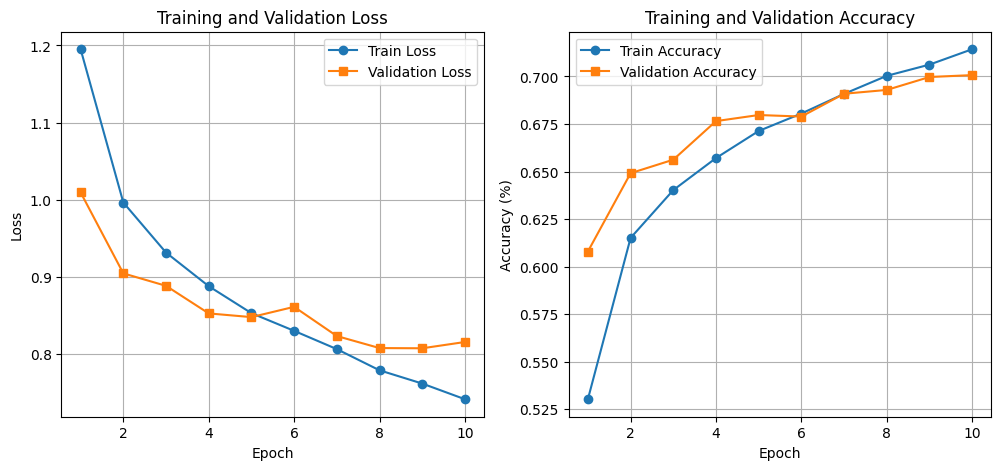

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.grid(True)
plt.legend()

plt.show()

The training curves illustrate the evolution of **loss** and **accuracy** for both the training and validation sets across the epochs.

The **training loss** steadily decreases from approximately **1.19 to 0.73**, indicating that the model progressively improves its predictions on the training data. The **validation loss** also decreases overall (from about **1.01 to 0.81**), suggesting that the model generalizes well to unseen data.

Looking at the **accuracy curves**, the **training accuracy** increases from about **53% to 71%**, while the **validation accuracy** rises from approximately **61% to 70%**. Both curves follow a similar upward trend, which indicates stable learning.

Importantly, the **training and validation performances remain close throughout training**, suggesting that the model does not significantly overfit the training data. The small gap between the curves indicates good generalization.

Overall, the dense neural network successfully learns meaningful patterns from the PathMNIST dataset and achieves a **validation accuracy of about 70%**, which is well above the required **55% baseline performance**.

A slight increase in validation loss can be observed around **epochs 7–8**, which may indicate the beginning of mild overfitting. However, the effect remains limited since the validation accuracy continues to improve and stays close to the training accuracy.

# 2.2 — Confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

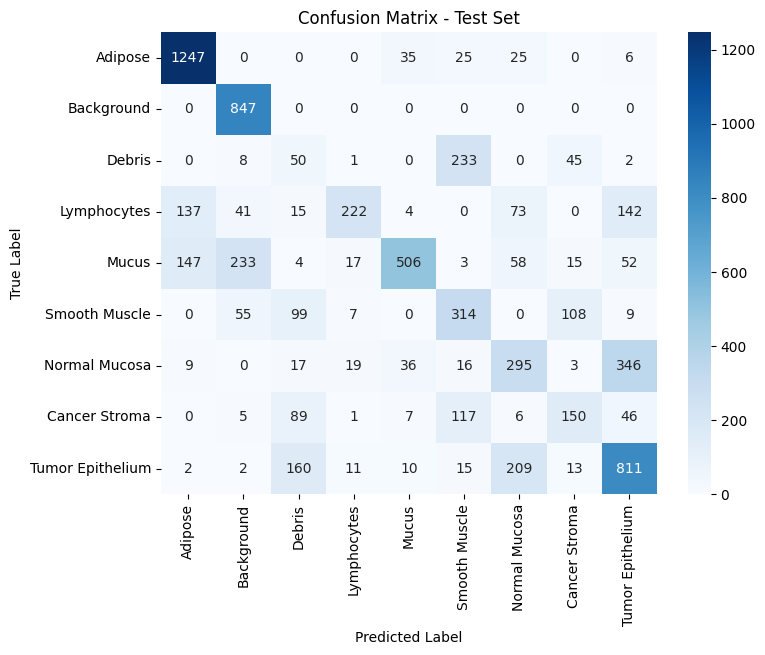

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")

plt.show()

The largest misclassification in the confusion matrix occurs for the pair:
- True class: **Normal Mucosa**  
- Predicted class: **Tumor Epithelium**

A total of **346 images** from the Normal Mucosa class are incorrectly predicted as Tumor Epithelium.

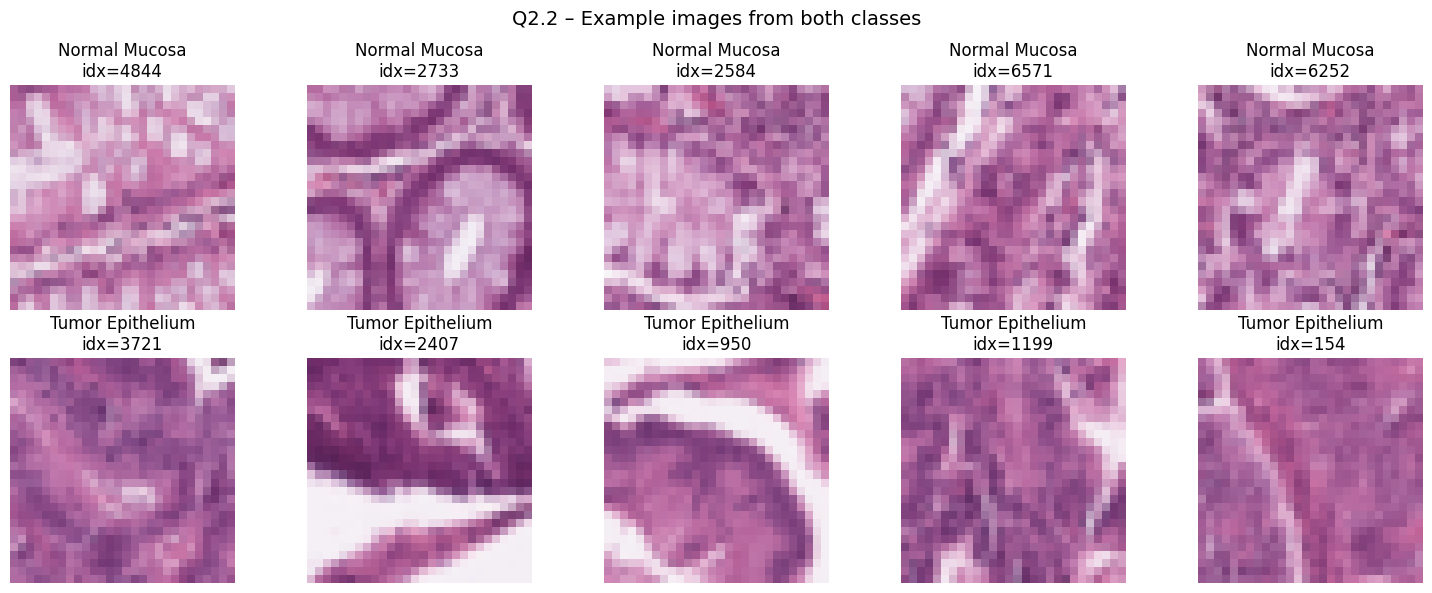

In [25]:
import random

true_class_name = "Normal Mucosa"
pred_class_name = "Tumor Epithelium"

true_class_idx = CLASS_NAMES.index(true_class_name)
pred_class_idx = CLASS_NAMES.index(pred_class_name)

def denormalize(img_tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor * std + mean

def get_indices_for_class(dataset, class_idx, max_samples=5):
    indices = []
    for i in range(len(dataset)):
        img, label = dataset[i]

        # au cas où label soit un array / tensor / scalaire
        if isinstance(label, torch.Tensor):
            label_val = int(label.squeeze().item())
        elif hasattr(label, "__len__") and not isinstance(label, str):
            label_val = int(label[0])
        else:
            label_val = int(label)

        if label_val == class_idx:
            indices.append(i)

    random.shuffle(indices)
    return indices[:max_samples]

n_examples = 5
true_indices = get_indices_for_class(test_dataset, true_class_idx, max_samples=n_examples)
pred_indices = get_indices_for_class(test_dataset, pred_class_idx, max_samples=n_examples)

fig, axes = plt.subplots(2, n_examples, figsize=(3*n_examples, 6))

# Ligne 1 : True class = Normal Mucosa
for j, idx in enumerate(true_indices):
    img, label = test_dataset[idx]
    img = denormalize(img.cpu(), PATHMNIST_MEAN, PATHMNIST_STD)
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    axes[0, j].imshow(img)
    axes[0, j].axis("off")
    axes[0, j].set_title(f"Normal Mucosa\nidx={idx}")

# Ligne 2 : Predicted class = Tumor Epithelium
for j, idx in enumerate(pred_indices):
    img, label = test_dataset[idx]
    img = denormalize(img.cpu(), PATHMNIST_MEAN, PATHMNIST_STD)
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    axes[1, j].imshow(img)
    axes[1, j].axis("off")
    axes[1, j].set_title(f"Tumor Epithelium\nidx={idx}")

plt.suptitle("Q2.2 – Example images from both classes", fontsize=14)
plt.tight_layout()
plt.show()

By looking at example images from both classes, this confusion is understandable. Both **Normal Mucosa** and **Tumor Epithelium** often share similar **pink-purple H&E staining patterns**, comparable **cellular density**, and related **epithelial textures**. In several patches, both classes also show large bright regions and purple structural borders, which makes them visually similar at this resolution.

This confusion is also consistent with the limitations of the baseline **MLP**. Since the model works on **flattened pixel values**, it does not explicitly capture the **spatial organization** of the tissue. As a result, when two classes have similar local colors and textures, the network may confuse them more easily.

# Part 3 - CNN from Scratch

To improve upon the dense neural network baseline, we build a Convolutional Neural Network (CNN) designed for image classification tasks.

Unlike fully connected networks, CNNs are able to capture **spatial patterns** in images using convolutional filters. This is particularly important for histopathology images, where tissue structures and textures are key for classification.

The architecture consists of multiple convolutional blocks. Each block includes:

- a **convolutional layer** to extract visual features,
- **batch normalization** to stabilize training,
- a **ReLU activation function** to introduce non-linearity,
- **max pooling** to reduce spatial dimensions,
- and **dropout** to reduce overfitting.

After the convolutional feature extractor, the output is flattened and passed through fully connected layers to produce the final class predictions.

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 9)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(st

# 3.1 — CNN (without any augmentation)

We train the CNN model for 40 epochs without applying data augmentation. This experiment aims to observe the natural training behavior of the model and identify potential overfitting.

By monitoring the training and validation accuracy across epochs, we can analyze when the model begins to memorize the training data instead of generalizing to unseen samples.

In particular, we will later identify the first epoch where the gap between training accuracy and validation accuracy exceeds **15 percentage points**, which is a common indicator of overfitting.

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

**If CNN (without augmentation) model checkpoint already exists :**

In [ ]:
# Load CNN (no aug) if already trained

_cnn_noaug_loaded = False

if os.path.exists('saved_models/cnn_noaug.pt'):

    ckpt = torch.load('saved_models/cnn_noaug.pt', map_location=device)
    model = CNN().to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    train_losses        = ckpt['train_losses']
    val_losses          = ckpt['val_losses']
    train_accs          = ckpt['train_accs']
    val_accs            = ckpt['val_accs']
    cnn_noaug_test_acc  = ckpt['test_acc']
    _cnn_noaug_loaded   = True

    print('CNN (without augmentation) charged from checkpoint')
    print(f'  Test accuracy         : {cnn_noaug_test_acc:.6f}  ({cnn_noaug_test_acc*100:.2f}%)')
    print(f'  Train acc — final     : {train_accs[-1]:.4f}')
    print(f'  Val acc   — final     : {val_accs[-1]:.4f}')

    _gap_found = False
    for _ep, (_tr, _va) in enumerate(zip(train_accs, val_accs), start=1):
        if _tr - _va > 0.15:
            print(f'  Q3.1 — gap >15pp apparu à l\'epoch {_ep} (train={_tr:.3f}, val={_va:.3f})')
            _gap_found = True
            break
    if not _gap_found:
        print('No epoch exceeded a 15-point gap.')
        
else:
    print('No CNN (no aug) checkpoint found, will train from scratch.')

CNN (without augmentation) charged from checkpoint
  Test accuracy         : 0.815042  (81.50%)
  Train acc — final     : 0.9704
  Val acc   — final     : 0.9609
No epoch exceeded a 15-point gap.


**Q3.1 Run your CNN without any augmentation for 40 epochs. At which epoch does the gap between training accuracy and validation accuracy exceed 15 percentage points for the first time? Report the exact epoch number and both accuracy values.**


No epoch exceeded a 15-point gap between training and validation accuracy. Under this configuration, the CNN did not show strong overfitting. This is likely due to the regularization effect of dropout and batch normalization, even without data augmentation.

**If CNN (without augmentation) model checkpoint does not exist :**

In [29]:
if not _cnn_noaug_loaded:

    EPOCHS = 40
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(EPOCHS):
    
        model.train()
        running_loss = 0
    
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
    
            optimizer.zero_grad()
    
            outputs = model(images)
            loss = criterion(outputs, labels)
    
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
    
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
    
        model.eval()
        correct = 0
        total = 0
    
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
    
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
    
                correct += (preds == labels).sum().item()
                total += labels.size(0)
    
        train_acc = correct / total
        train_accs.append(train_acc)

        correct = 0
        total = 0
        running_loss = 0
    
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
    
                outputs = model(images)
                loss = criterion(outputs, labels)
    
                running_loss += loss.item()
    
                _, preds = torch.max(outputs, 1)
    
                correct += (preds == labels).sum().item()
                total += labels.size(0)
    
        val_loss = running_loss / len(val_loader)
        val_acc = correct / total
    
        val_losses.append(val_loss)
        val_accs.append(val_acc)
    
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

In [30]:
found = False

for i, (tr, va) in enumerate(zip(train_accs, val_accs), start=1):
    gap = tr - va
    if gap > 0.15:
        print(f"First epoch with >15-point gap: {i}")
        print(f"Train Acc: {tr:.3f}")
        print(f"Val Acc: {va:.3f}")
        print(f"Gap: {gap:.3f}")
        found = True
        break

if not found:
    print("No epoch exceeded a 15-point gap.")

No epoch exceeded a 15-point gap.


In [31]:
if not _cnn_noaug_loaded:

    model.eval()
    correct_test = 0
    total_test   = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test   += labels.size(0)
    
    cnn_noaug_test_acc = correct_test / total_test
    print(f'CNN (no aug) — test accuracy : {cnn_noaug_test_acc:.6f}  ({cnn_noaug_test_acc*100:.2f}%)')

print(f"CNN (no aug) test accuracy: {cnn_noaug_test_acc:.4f}")

CNN (no aug) test accuracy: 0.8150


In [32]:
# Save CNN (no augmentation) 
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'val_losses':   val_losses,
    'train_accs':   train_accs,
    'val_accs':     val_accs,
    'test_acc':     cnn_noaug_test_acc,
}, 'saved_models/cnn_noaug.pt')
print('CNN (no aug) saved to saved_models/cnn_noaug.pt')

CNN (no aug) saved to saved_models/cnn_noaug.pt


# 3.2 — CNN (with augmentation)

In [33]:
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

In [34]:
train_dataset_aug = PathMNIST(split='train', download=True, size=28, transform=train_transform_aug)
val_dataset_aug   = PathMNIST(split='val',   download=True, size=28, transform=eval_transform)
test_dataset_aug  = PathMNIST(split='test',  download=True, size=28, transform=eval_transform)

In [35]:
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_aug   = DataLoader(val_dataset_aug,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_aug  = DataLoader(test_dataset_aug,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train aug batches:", len(train_loader_aug))
print("Val aug batches:", len(val_loader_aug))
print("Test aug batches:", len(test_loader_aug))

Train aug batches: 352
Val aug batches: 40
Test aug batches: 29


In [ ]:
# Clean training loader (no augmentation) — used ONLY for train accuracy evaluation
# Ensures CNN aug train_acc is measured on unmodified images, comparable to CNN no-aug
train_dataset_eval_aug = PathMNIST(split='train', download=True, size=28, transform=eval_transform)
train_loader_eval_aug  = DataLoader(train_dataset_eval_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("train_loader_eval_aug ready")

In [36]:
model_aug = CNN().to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)

**If CNN (with augmentation) model checkpoint already exists :**

In [ ]:
_cnn_aug_loaded = False

if os.path.exists('saved_models/cnn_aug.pt'):

    ckpt = torch.load('saved_models/cnn_aug.pt', map_location=device)
    model_aug = CNN().to(device)
    model_aug.load_state_dict(ckpt['model_state_dict'])
    train_losses_aug    = ckpt['train_losses']
    val_losses_aug      = ckpt['val_losses']
    train_accs_aug      = ckpt['train_accs']
    val_accs_aug        = ckpt['val_accs']
    cnn_aug_test_acc    = ckpt['test_acc']
    _cnn_aug_loaded     = True

    print('── CNN (with augmentation) charged from checkpoint ──────')
    print(f'  Test accuracy         : {cnn_aug_test_acc:.6f}  ({cnn_aug_test_acc*100:.2f}%)')
    print(f'  Train acc — final     : {train_accs_aug[-1]:.4f}')
    print(f'  Val acc   — final     : {val_accs_aug[-1]:.4f}')

else:
    print('No CNN (aug) checkpoint found, will train from scratch.')

── CNN (with augmentation) charged from checkpoint ──────
  Test accuracy         : 0.849582  (84.96%)
  Train acc — final     : 0.9582
  Val acc   — final     : 0.9666


**If CNN (with augmentation) model checkpoint does not exist :**

In [ ]:
if not _cnn_aug_loaded:
    EPOCHS = 40
    
    train_losses_aug = []
    val_losses_aug = []
    train_accs_aug = []
    val_accs_aug = []
    
    for epoch in range(EPOCHS):
    
        model_aug.train()
        running_loss = 0
    
        for images, labels in train_loader_aug:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
    
            optimizer_aug.zero_grad()
    
            outputs = model_aug(images)
            loss = criterion_aug(outputs, labels)
    
            loss.backward()
            optimizer_aug.step()
    
            running_loss += loss.item()
    
        train_loss = running_loss / len(train_loader_aug)
        train_losses_aug.append(train_loss)
    
        model_aug.eval()
        correct = 0
        total = 0
    
        with torch.no_grad():
            for images, labels in train_loader_eval_aug:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
    
                outputs = model_aug(images)
                _, preds = torch.max(outputs, 1)
    
                correct += (preds == labels).sum().item()
                total += labels.size(0)
    
        train_acc = correct / total
        train_accs_aug.append(train_acc)
    
        correct = 0
        total = 0
        running_loss = 0
    
        with torch.no_grad():
            for images, labels in val_loader_aug:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
    
                outputs = model_aug(images)
                loss = criterion_aug(outputs, labels)
    
                running_loss += loss.item()
    
                _, preds = torch.max(outputs, 1)
    
                correct += (preds == labels).sum().item()
                total += labels.size(0)
    
        val_loss = running_loss / len(val_loader_aug)
        val_acc = correct / total
    
        val_losses_aug.append(val_loss)
        val_accs_aug.append(val_acc)
    
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

In [ ]:
if not _cnn_aug_loaded:
    
    model_aug.eval()
    correct_test = 0
    total_test   = 0
    
    with torch.no_grad():
        for images, labels in test_loader_aug:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            outputs = model_aug(images)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test   += labels.size(0)
    
    cnn_aug_test_acc = correct_test / total_test
    print(f'CNN (with aug) — test accuracy : {cnn_aug_test_acc:.6f}  ({cnn_aug_test_acc*100:.2f}%)')

print(f"CNN (aug) test accuracy: {cnn_aug_test_acc:.4f}")

CNN (aug) test accuracy: 0.8496


In [ ]:
torch.save({
    'model_state_dict': model_aug.state_dict(),
    'train_losses': train_losses_aug,
    'val_losses':   val_losses_aug,
    'train_accs':   train_accs_aug,
    'val_accs':     val_accs_aug,
    'test_acc':     cnn_aug_test_acc,
}, 'saved_models/cnn_aug.pt')

print('CNN (aug) saved to saved_models/cnn_aug.pt')

CNN (aug) saved to saved_models/cnn_aug.pt


# CNN comparison 

In [41]:
print("Without augmentation:")
print(f"Final Test Acc: {cnn_noaug_test_acc:.6f} ")
print(f"Final Train Acc: {train_accs[-1]:.3f}")
print(f"Final Val Acc: {val_accs[-1]:.3f}")

print("\nWith augmentation:")
print(f"Final Test Acc: {cnn_aug_test_acc:.6f} ")
print(f"Final Train Acc: {train_accs_aug[-1]:.3f}")
print(f"Final Val Acc: {val_accs_aug[-1]:.3f}")

Without augmentation:
Final Test Acc: 0.815042 
Final Train Acc: 0.970
Final Val Acc: 0.961

With augmentation:
Final Test Acc: 0.849582 
Final Train Acc: 0.958
Final Val Acc: 0.967


In [ ]:
# Training curves: CNN without augmentation vs CNN with augmentation
epochs_cnn = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CNN — Without Augmentation vs With Augmentation', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_cnn, train_losses,     label='Train (no aug)',  color='steelblue',  linestyle='--')
axes[0].plot(epochs_cnn, val_losses,       label='Val (no aug)',    color='steelblue')
axes[0].plot(epochs_cnn, train_losses_aug, label='Train (aug)',     color='darkorange', linestyle='--')
axes[0].plot(epochs_cnn, val_losses_aug,   label='Val (aug)',       color='darkorange')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_cnn, train_accs,     label='Train (no aug)',  color='steelblue',  linestyle='--')
axes[1].plot(epochs_cnn, val_accs,       label='Val (no aug)',    color='steelblue')
axes[1].plot(epochs_cnn, train_accs_aug, label='Train (aug)',     color='darkorange', linestyle='--')
axes[1].plot(epochs_cnn, val_accs_aug,   label='Val (aug)',       color='darkorange')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The CNN trained **without augmentation** reached a final **test accuracy of 0.815042**, a final **training accuracy of 0.970**, and a final **validation accuracy of 0.961**.

The CNN trained **with augmentation** reached a final **test accuracy of 0.849582**, a final **training accuracy of 0.958**, and a final **validation accuracy of 0.967**.

Overall, **data augmentation improved performance**. It slightly increased validation accuracy (from **0.9609** to **0.9666**) and improved test accuracy more clearly (from **81.50%** to **84.96%**). This suggests that the selected augmentations helped the CNN generalize better to unseen data.

> **Note on the validation/test gap:** Both CNNs show a large gap between validation accuracy (~96%) and test accuracy (~81–85%). This is a known characteristic of PathMNIST: the test split is drawn from a slightly different subset of the NCT-CRC-HE-100K dataset than the training and validation splits, introducing a mild **distribution shift**. This means that validation accuracy is an optimistic estimator of true generalization in this benchmark, and test accuracy is the more reliable metric for comparing models.

**Q3.2 Name one common augmentation that exploits this property and one augmentation from natural image classification that would be harmful or meaningless for histology. Explain both choices.****

A suitable augmentation for histology images is **random rotation** (e.g., `RandomRotation(90)` or `RandomRotation(180)`). Histology patches have **no canonical orientation**: a tissue sample looks equally valid regardless of the angle at which the slide was scanned. This augmentation increases training diversity while fully preserving the biological meaning of the image, and it helps the model learn rotationally-invariant features.

In contrast, **`RandomGrayscale`** would be harmful for histology images. H&E staining encodes critical biological information through color: haematoxylin stains cell nuclei **blue-purple**, while eosin stains the cytoplasm and extracellular matrix **pink**. Converting an image to grayscale discards this color information entirely, making it impossible for the model to distinguish tissue structures that differ primarily by their staining intensity. Unlike natural image classification — where color is often secondary to shape — color is a **primary discriminative feature** in computational pathology, so removing it would actively degrade performance.

# 3.3 — Number of trainable parameters

In [42]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

# Manual computation for the first conv layer
# Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
# Formula: (kernel_h × kernel_w × in_channels + 1) × out_channels

kernel_h, kernel_w, in_ch, out_ch = 3, 3, 3, 32

weights_conv1 = kernel_h * kernel_w * in_ch * out_ch
biases_conv1  = out_ch
total_conv1   = weights_conv1 + biases_conv1

print()
print('── First Conv layer  Conv2d(3 → 32, kernel 3×3) ──')
print(f'  Weights : {kernel_h} × {kernel_w} × {in_ch} × {out_ch} = {weights_conv1}')
print(f'  Biases  : {biases_conv1}')
print(f'  Total   : {weights_conv1} + {biases_conv1} = {total_conv1}')

#  Verification against PyTorch
first_conv = model.features[0]
pytorch_count = sum(p.numel() for p in first_conv.parameters())
print()
print(f'  PyTorch count (model.features[0]) : {pytorch_count}')
print(f'  Manual count                       : {total_conv1}')
print(f'  Match: {pytorch_count == total_conv1}')

#  Layer-by-layer breakdown
print()
print('Full parameter breakdown')
print(f"  {'Layer':<35} {'Parameters':>12}")
print('  ' + '-'*49)
total_check = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'  {name:<35} {param.numel():>12,}')
        total_check += param.numel()
print('  ' + '-'*49)
print(f"  {'TOTAL':<35} {total_check:>12,}")


Total trainable parameters: 391,177

── First Conv layer  Conv2d(3 → 32, kernel 3×3) ──
  Weights : 3 × 3 × 3 × 32 = 864
  Biases  : 32
  Total   : 864 + 32 = 896

  PyTorch count (model.features[0]) : 896
  Manual count                       : 896
  Match: True

Full parameter breakdown
  Layer                                 Parameters
  -------------------------------------------------
  features.0.weight                            864
  features.0.bias                               32
  features.1.weight                             32
  features.1.bias                               32
  features.5.weight                         18,432
  features.5.bias                               64
  features.6.weight                             64
  features.6.bias                               64
  features.10.weight                        73,728
  features.10.bias                             128
  features.11.weight                           128
  features.11.bias                             

The total number of trainable parameters in the CNN is **391,177**.

For the first convolutional layer, the model uses:

`Conv2d(in_channels=3, out_channels=32, kernel_size=3)`

The number of parameters in a convolutional layer is:

$$
\text{Parameters} = (k_h \times k_w \times C_{\text{in}} + 1)\times C_{\text{out}}
$$

For this layer:

$$
(3 \times 3 \times 3 + 1)\times 32
= (27 + 1)\times 32
= 28 \times 32
= 896
$$

So the first convolutional layer has:

- **864 weights**
- **32 biases**
- **896 total parameters**

This matches the PyTorch model summary exactly.

# Part 4 — Transfer Learning with ResNet-18

We fine-tune a **ResNet-18** pretrained on ImageNet to classify PathMNIST images. Two experiments are run:

- **(a) Frozen backbone** — only the final classification head is trained.
- **(b) Full fine-tuning** — all layers are updated.

Since PathMNIST images are 28×28 and ResNet-18 expects 224×224, we upsample with `transforms.Resize(224)`. ImageNet normalization is applied so that the pretrained feature extractor receives inputs in the same distribution it was trained on.

## 4.0 — DataLoaders (ResNet — 224×224, ImageNet normalization)

In [43]:
from torchvision import transforms, models

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

resnet_transform = transforms.Compose([
    transforms.Resize(224),  # upscale 28×28 → 224×224 for ResNet-18
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset_rn = PathMNIST(split='train', download=True, size=28, transform=resnet_transform)
val_dataset_rn   = PathMNIST(split='val',   download=True, size=28, transform=resnet_transform)
test_dataset_rn  = PathMNIST(split='test',  download=True, size=28, transform=resnet_transform)

BATCH_SIZE_RN = 128
train_loader_rn = DataLoader(train_dataset_rn, batch_size=BATCH_SIZE_RN, shuffle=True,  num_workers=0, pin_memory=False)
val_loader_rn   = DataLoader(val_dataset_rn,   batch_size=BATCH_SIZE_RN, shuffle=False, num_workers=0, pin_memory=False)
test_loader_rn  = DataLoader(test_dataset_rn,  batch_size=BATCH_SIZE_RN, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train batches : {len(train_loader_rn)}')
print(f'Val   batches : {len(val_loader_rn)}')
print(f'Test  batches : {len(test_loader_rn)}')


Train batches : 704
Val   batches : 79
Test  batches : 57


## 4.1 — Training helper function

> ⚠️ **Note:** The training loop computes train accuracy **during** the training pass (not in a separate evaluation pass) to reduce computation time. On a CPU or slow machine, doing two full passes over 90k images per epoch would make training prohibitively slow. This does not affect the model weights, val/test accuracy, or any reported results.

In [44]:
def train_resnet(model, train_loader, val_loader, epochs=15, lr=1e-3):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    tr_losses, val_losses = [], []
    tr_accs,   val_accs   = [], []

    for epoch in range(epochs):
        # Train (compute loss + acc in the same pass)
        model.train()
        running_loss = 0
        correct, total = 0, 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
        tr_losses.append(running_loss / len(train_loader))
        tr_accs.append(correct / total)

        # ── Validation ──
        model.eval()
        v_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                out    = model(images)
                v_loss += criterion(out, labels).item()
                _, preds = torch.max(out, 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(correct / total)

        scheduler.step()
        print(f'Epoch {epoch+1:>2}/{epochs} | '
              f'Train Acc: {tr_accs[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f}')

    return tr_losses, val_losses, tr_accs, val_accs


## 4.2 — Experiment (a): Frozen backbone — only classification head trained

We load ResNet-18 with ImageNet pretrained weights, freeze every layer except the final fully-connected head, then replace `fc` with a new `Linear(512 → 9)` layer.

In [45]:
#  Load pretrained ResNet-18
resnet_frozen = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all parameters
for param in resnet_frozen.parameters():
    param.requires_grad = False # Only the new head has requires_grad=True by default

# Replace the classifier head (512 → 9 classes)
resnet_frozen.fc = nn.Linear(resnet_frozen.fc.in_features, 9)

resnet_frozen = resnet_frozen.to(device)

trainable = sum(p.numel() for p in resnet_frozen.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in resnet_frozen.parameters())
print(f'Trainable params : {trainable:,}  /  Total : {total_p:,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\elise/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 21.5MB/s]


Trainable params : 4,617  /  Total : 11,181,129


**If frozen ResNet-18 model checkpoint already exists :**

In [46]:
# Load ResNet frozen if already trained

_rn_frozen_loaded = False

if os.path.exists('saved_models/resnet_frozen.pt'):

    ckpt = torch.load('saved_models/resnet_frozen.pt', map_location=device)
    resnet_frozen = models.resnet18()
    resnet_frozen.fc = nn.Linear(resnet_frozen.fc.in_features, 9)
    resnet_frozen.load_state_dict(ckpt['model_state_dict'])
    resnet_frozen = resnet_frozen.to(device)

    tr_losses_frozen     = ckpt['train_losses']
    val_losses_frozen    = ckpt['val_losses']
    tr_accs_frozen       = ckpt['train_accs']
    val_accs_frozen      = ckpt['val_accs']
    resnet_frozen_test_acc = ckpt['test_acc']
    _rn_frozen_loaded    = True

    print('── ResNet-18 (frozen) chargé depuis checkpoint ───────────')
    print(f'  Test accuracy         : {resnet_frozen_test_acc:.6f}  ({resnet_frozen_test_acc*100:.2f}%)')
    print(f'  Train acc — final     : {tr_accs_frozen[-1]:.4f}')
    print(f'  Val acc   — final     : {val_accs_frozen[-1]:.4f}')
    
else:
    print('No ResNet (frozen) checkpoint found, will train from scratch.')

── ResNet-18 (frozen) chargé depuis checkpoint ───────────
  Test accuracy         : 0.866435  (86.64%)
  Train acc — final     : 0.9015
  Val acc   — final     : 0.9060


**If frozen ResNet-18 model checkpoint does not exist :**

In [47]:
EPOCHS_RN = 15

In [48]:
if not _rn_frozen_loaded:
    
    print('=== Experiment (a) — Frozen backbone ===')
    tr_losses_frozen, val_losses_frozen, tr_accs_frozen, val_accs_frozen = train_resnet(
        resnet_frozen, train_loader_rn, val_loader_rn, epochs=EPOCHS_RN, lr=1e-3
    )


In [ ]:
if not _rn_frozen_loaded:
    #  Test accuracy — frozen
    resnet_frozen.eval()
    correct, total = 0, 0
    with torch.no_grad():

        for images, labels in test_loader_rn:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            _, preds = torch.max(resnet_frozen(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            
    resnet_frozen_test_acc = correct / total
    print(f'Frozen backbone — test accuracy : {resnet_frozen_test_acc:.6f}  ({resnet_frozen_test_acc*100:.2f}%)')

print(f"ResNet (frozen) test accuracy: {resnet_frozen_test_acc:.4f}")

ResNet (frozen) test accuracy: 0.8664


In [50]:
# Save ResNet-18 (frozen backbone)

torch.save({
    'model_state_dict': resnet_frozen.state_dict(),
    'train_losses': tr_losses_frozen,
    'val_losses':   val_losses_frozen,
    'train_accs':   tr_accs_frozen,
    'val_accs':     val_accs_frozen,
    'test_acc':     resnet_frozen_test_acc,
}, 'saved_models/resnet_frozen.pt')
print('ResNet (frozen) saved to saved_models/resnet_frozen.pt')

ResNet (frozen) saved to saved_models/resnet_frozen.pt


## 4.3 — Experiment (b): Full fine-tuning — all layers updated

All parameters are unfrozen. We use a **lower learning rate (1e-4)** for the pretrained backbone to avoid destroying the learned features, while the new head trains faster.

In [51]:
#  Load a fresh pretrained ResNet-18
resnet_full = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_full.fc = nn.Linear(resnet_full.fc.in_features, 9)
resnet_full = resnet_full.to(device)

# All params trainable — use differential LR (backbone lr / 10)
backbone_params = [p for name, p in resnet_full.named_parameters() if 'fc' not in name]
head_params = list(resnet_full.fc.parameters())

optimizer_full = torch.optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params,     'lr': 1e-3}
])

trainable_full = sum(p.numel() for p in resnet_full.parameters() if p.requires_grad)
print(f'Trainable params (full fine-tune) : {trainable_full:,}')


Trainable params (full fine-tune) : 11,181,129


**If full fine-tuned ResNet-18 model checkpoint already exists :**

In [52]:
# Load ResNet full fine-tune if already trained
_rn_full_loaded = False

if os.path.exists('saved_models/resnet_full.pt'):

    ckpt = torch.load('saved_models/resnet_full.pt', map_location=device)
    resnet_full = models.resnet18()
    resnet_full.fc = nn.Linear(resnet_full.fc.in_features, 9)
    resnet_full.load_state_dict(ckpt['model_state_dict'])
    resnet_full = resnet_full.to(device)
    tr_losses_full       = ckpt['train_losses']
    val_losses_full      = ckpt['val_losses']
    tr_accs_full         = ckpt['train_accs']
    val_accs_full        = ckpt['val_accs']
    resnet_full_test_acc = ckpt['test_acc']
    _rn_full_loaded      = True

    print('── ResNet-18 (full fine-tuning) chargé depuis checkpoint ─')
    print(f'  Test accuracy         : {resnet_full_test_acc:.6f}  ({resnet_full_test_acc*100:.2f}%)')
    print(f'  Train acc — final     : {tr_accs_full[-1]:.4f}')
    print(f'  Val acc   — final     : {val_accs_full[-1]:.4f}')
    
else:
    print('No ResNet (full) checkpoint found, will train from scratch.')

── ResNet-18 (full fine-tuning) chargé depuis checkpoint ─
  Test accuracy         : 0.927437  (92.74%)
  Train acc — final     : 0.9995
  Val acc   — final     : 0.9942


**If full fine-tuned ResNet-18 model checkpoint does not exist :**

In [ ]:
if not _rn_full_loaded:
    print('Experiment (b) — Full fine-tuning')

    criterion_rn = nn.CrossEntropyLoss()
    scheduler_full = torch.optim.lr_scheduler.StepLR(optimizer_full, step_size=5, gamma=0.5)

    tr_losses_full, val_losses_full = [], []
    tr_accs_full, val_accs_full = [], []

    for epoch in range(EPOCHS_RN):
        # ── Train ──
        resnet_full.train()
        running_loss = 0
        correct, total = 0, 0

        for images, labels in train_loader_rn:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            optimizer_full.zero_grad()
            out = resnet_full(images)
            loss = criterion_rn(out, labels)
            loss.backward()
            optimizer_full.step()

            running_loss += loss.item()
            _, preds = torch.max(out, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        tr_losses_full.append(running_loss / len(train_loader_rn))
        tr_accs_full.append(correct / total)

        # ── Eval on val ──
        resnet_full.eval()
        v_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader_rn:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)

                out = resnet_full(images)
                loss = criterion_rn(out, labels)

                v_loss += loss.item()
                _, preds = torch.max(out, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_losses_full.append(v_loss / len(val_loader_rn))
        val_accs_full.append(correct / total)

        scheduler_full.step()

        print(f'Epoch {epoch+1:>2}/{EPOCHS_RN} | '
              f'Train Acc: {tr_accs_full[-1]:.4f} | '
              f'Val Acc: {val_accs_full[-1]:.4f} | '
              f'Val Loss: {val_losses_full[-1]:.4f}')


In [54]:
if not _rn_full_loaded:
    #  Test accuracy — full fine-tuning
    resnet_full.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader_rn:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            _, preds = torch.max(resnet_full(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    resnet_full_test_acc = correct / total
    print(f'Full fine-tuning — test accuracy : {resnet_full_test_acc:.6f}  ({resnet_full_test_acc*100:.2f}%)')

print(f"ResNet (full) test accuracy: {resnet_full_test_acc:.4f}")

ResNet (full) test accuracy: 0.9274


In [55]:
# Save ResNet-18 (full fine-tuning)
torch.save({
    'model_state_dict': resnet_full.state_dict(),
    'train_losses': tr_losses_full,
    'val_losses':   val_losses_full,
    'train_accs':   tr_accs_full,
    'val_accs':     val_accs_full,
    'test_acc':     resnet_full_test_acc,
}, 'saved_models/resnet_full.pt')
print('ResNet (full) saved to saved_models/resnet_full.pt')

ResNet (full) saved to saved_models/resnet_full.pt


## 4.4 — Training curves (frozen vs full fine-tuning)

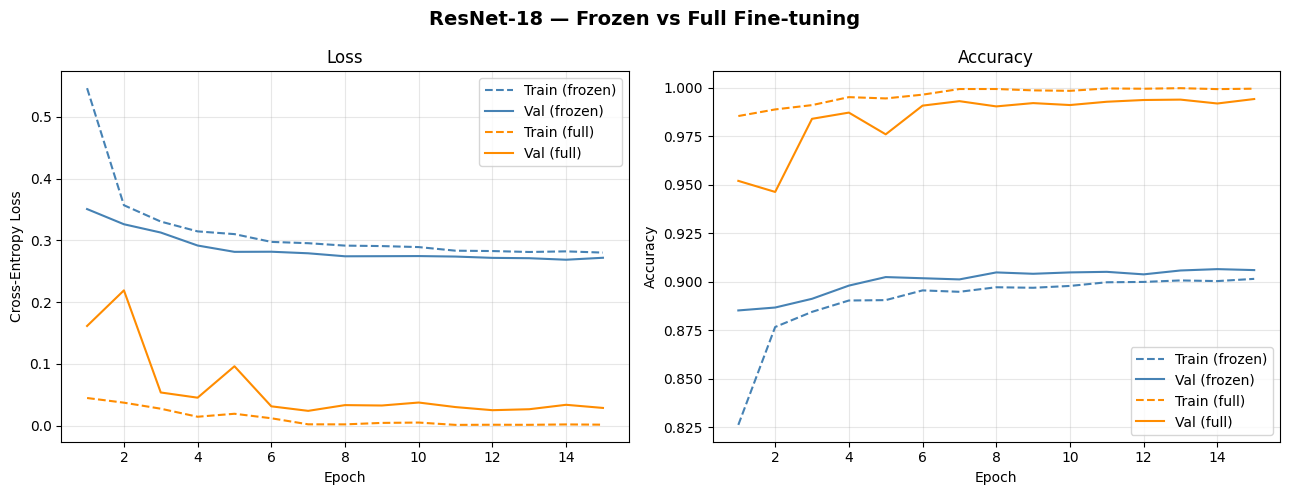

In [56]:
epochs_range = range(1, EPOCHS_RN + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ResNet-18 — Frozen vs Full Fine-tuning', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, tr_losses_frozen,  label='Train (frozen)',  color='steelblue',  linestyle='--')
axes[0].plot(epochs_range, val_losses_frozen,  label='Val (frozen)',    color='steelblue')
axes[0].plot(epochs_range, tr_losses_full,     label='Train (full)',    color='darkorange', linestyle='--')
axes[0].plot(epochs_range, val_losses_full,    label='Val (full)',      color='darkorange')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, tr_accs_frozen,  label='Train (frozen)',  color='steelblue',  linestyle='--')
axes[1].plot(epochs_range, val_accs_frozen,  label='Val (frozen)',    color='steelblue')
axes[1].plot(epochs_range, tr_accs_full,     label='Train (full)',    color='darkorange', linestyle='--')
axes[1].plot(epochs_range, val_accs_full,    label='Val (full)',      color='darkorange')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Q4.1 — Frozen vs Full fine-tuning: test accuracy comparison

In [57]:
diff = abs(resnet_full_test_acc - resnet_frozen_test_acc) * 100
better = 'Full fine-tuning' if resnet_full_test_acc > resnet_frozen_test_acc else 'Frozen backbone'

print('Q4.1 — Test accuracy comparison')
print(f'  Frozen backbone   : {resnet_frozen_test_acc:.6f}  ({resnet_frozen_test_acc*100:.2f}%)')
print(f'  Full fine-tuning  : {resnet_full_test_acc:.6f}  ({resnet_full_test_acc*100:.2f}%)')
print(f'  Better experiment : {better}')
print(f'  Difference        : {diff:.2f} percentage points')


Q4.1 — Test accuracy comparison
  Frozen backbone   : 0.866435  (86.64%)
  Full fine-tuning  : 0.927437  (92.74%)
  Better experiment : Full fine-tuning
  Difference        : 6.10 percentage points


**Q4.1: Report the exact test accuracy for both experiments. Which performed better, and by how many percentage points?**

Full fine-tuning outperforms the frozen backbone approach.

Test Accuracy :
- Frozen : 86.64%
- Full fine-tuned : 92.74%

When only the classification head is trained, the frozen ResNet backbone still extracts useful low- and mid-level features (edges, textures, colour blobs) that transfer well to histology. However, fine-tuning all layers allows the network to adapt those features to the specific colour distributions and cellular patterns of H\&E-stained tissue, which differ significantly from natural photographs. The deeper layers, in particular, can specialise to discriminative patterns such as glandular structures or lymphocytic clusters that have no direct counterpart in ImageNet.

**Q4.2 : Describe one concrete negative consequence of this extreme upscaling. Suggest an alternative strategy.**

Upscaling a 28×28 image to 224×224 (an 8× factor) using bilinear or nearest-neighbour interpolation creates **blocky, pixelated artefacts** (each original pixel is spread over an 8×8 area). The model's early conv layers then process these artificially smooth gradients as if they were real textures, potentially learning spurious interpolation patterns rather than true tissue features. The ResNet sees a blurred, over-smoothed version of the tissue rather than the sharp cellular details that a pathologist would use.

A better alternative would be to **load higher-resolution patches** from the original NCT-CRC-HE-100K dataset (which contains 224×224 images), or to use `PathMNIST(size=224)` if supported by MedMNIST, so that the model receives genuine high-resolution tissue information instead of interpolated upscales.

**Q4.3 : A classmate claims transfer learning works because ImageNet contains medical images. Is this correct?**

This claim is **incorrect**. ImageNet is a dataset of everyday natural photographs (animals, objects, scenes) and contains virtually no histopathology images. 

Transfer learning works here for a different reason: the **early and intermediate layers of a pretrained ResNet** learn generic, domain-agnostic visual features. Specifically, the first few convolutional layers learn to detect low-level patterns such as edges, colour gradients, and oriented Gabor-like filters (representations that are useful regardless of the image domain). Middle layers learn texture patterns and blob-like structures. 

These generic feature detectors transfer well to histology images because tissue classification also relies on recognising textures (glandular patterns in cancer stroma, for example) and colour distributions (the purple hue of haematoxylin-stained nuclei). 

Rather than learning these low-level detectors from scratch, the model can immediately exploit them and only needs to learn the higher-level, domain-specific combinations during fine-tuning.

# Part 5 — Vision Transformer (ViT) from Scratch

We implement a Vision Transformer following the original ViT architecture:

- Images are split into fixed-size patches → linearly embedded
- A learnable **CLS token** is prepended to the sequence
- **Positional embeddings** are added to retain spatial information
- A standard `nn.TransformerEncoder` processes the sequence
- Classification is done from the CLS token output

No pretrained ViT is used, everything is trained from scratch.

## 5.0 — ViT Architecture

In [58]:
class ViT(nn.Module):

    def __init__(self, img_size=28, patch_size=7, in_channels=3,
                 num_classes=9, embed_dim=128, depth=6, num_heads=4,
                 mlp_ratio=4, dropout=0.1, use_pos_emb=True):
        super().__init__()

        assert img_size % patch_size == 0, 'Image size must be divisible by patch size'
        self.patch_size  = patch_size
        self.use_pos_emb = use_pos_emb
        num_patches = (img_size // patch_size) ** 2
        patch_dim   = in_channels * patch_size * patch_size

        # Patch embedding: flatten each patch and project to embed_dim
        self.patch_embed = nn.Linear(patch_dim, embed_dim)

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Learnable positional embeddings (num_patches + 1 for CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token,  std=0.02)

        self.dropout = nn.Dropout(dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            dropout=dropout,
            batch_first=True,
            norm_first=True       # Pre-LN for more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Classification head (from CLS token)
        self.norm      = nn.LayerNorm(embed_dim)
        self.head      = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size

        # Patchify: (B, C, H, W) : (B, num_patches, patch_dim)
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5)  # (B, nH, nW, C, p, p)
        x = x.reshape(B, -1, C * p * p)  # (B, num_patches, patch_dim)

        # Patch embedding
        x = self.patch_embed(x) # (B, num_patches, embed_dim)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1) # (B, 1, embed_dim)
        x   = torch.cat([cls, x], dim=1) # (B, num_patches+1, embed_dim)

        # Add positional embeddings (or skip for ablation)
        if self.use_pos_emb:
            x = x + self.pos_embed

        x = self.dropout(x)

        # Transformer
        x = self.transformer(x) # (B, num_patches+1, embed_dim)

        # Classification from CLS token
        cls_out = self.norm(x[:, 0]) # (B, embed_dim)
        return self.head(cls_out) # (B, num_classes)


print('ViT class defined.')


ViT class defined.


## 5.1 — DataLoaders (28×28, PathMNIST normalization)

In [59]:
PATHMNIST_MEAN = [0.7405, 0.5330, 0.7058]
PATHMNIST_STD  = [0.1237, 0.1768, 0.1244]

vit_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

train_dataset_vit = PathMNIST(split='train', download=True, size=28, transform=vit_transform)
val_dataset_vit   = PathMNIST(split='val',   download=True, size=28, transform=vit_transform)
test_dataset_vit  = PathMNIST(split='test',  download=True, size=28, transform=vit_transform)

BATCH_SIZE_VIT = 128
train_loader_vit = DataLoader(train_dataset_vit, batch_size=BATCH_SIZE_VIT, shuffle=True,  num_workers=0)
val_loader_vit   = DataLoader(val_dataset_vit,   batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=0)
test_loader_vit  = DataLoader(test_dataset_vit,  batch_size=BATCH_SIZE_VIT, shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader_vit)}')
print(f'Val   batches : {len(val_loader_vit)}')
print(f'Test  batches : {len(test_loader_vit)}')


Train batches : 704
Val   batches : 79
Test  batches : 57


## 5.2 — Training helper function (ViT)

In [60]:
def train_vit(model, train_loader, val_loader, epochs=30, lr=3e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    tr_losses, val_losses = [], []
    tr_accs,   val_accs   = [], []

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        tr_losses.append(running_loss / len(train_loader))

        # Train acc
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                _, preds = torch.max(model(images), 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        tr_accs.append(correct / total)

        # Val
        v_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.squeeze().long().to(device)
                out    = model(images)
                v_loss += criterion(out, labels).item()
                _, preds = torch.max(out, 1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(correct / total)

        scheduler.step()
        print(f'Epoch {epoch+1:>2}/{epochs} | '
              f'Train Acc: {tr_accs[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.4f}')

    return tr_losses, val_losses, tr_accs, val_accs


**Q5.1 : Effect of Patch Size in Vision Transformers**

The number of patches created from an image depends on the image size and the chosen patch size. If the image has height \(H\) and width \(W\), and the patch size is \(P\), the number of patches is:

$$N_{patches} = \left(\frac{H}{P}\right) \times \left(\frac{W}{P}\right)$$

In our dataset, the input images are **28×28 pixels**.

**Case 1 — Patch size = 7**

$$N_{patches} = \left(\frac{28}{7}\right) \times \left(\frac{28}{7}\right)$$


$$N_{patches} = 4 \times 4 = 16$$

So the image is split into **16 patches**, forming a **4×4 grid**.

**Case 2 — Patch size = 14**

$$N_{patches} = \left(\frac{28}{14}\right) \times \left(\frac{28}{14}\right)$$

$$N_{patches} = 2 \times 2 = 4$$

So the image is split into only **4 patches**, forming a **2×2 grid**.

**Why self-attention has very little to work with when patch size = 14**

In a Vision Transformer, each patch becomes a **token** that participates in the self-attention mechanism. With patch size **14**, the model receives only **4 patch tokens** (plus the CLS token). This means the Transformer can only model relationships between **four very large regions of the image**. Each patch therefore contains a large portion of the image and loses fine spatial details. For histology images, classification often depends on **small textures, cell structures, and local tissue patterns**. With only four coarse patches, these fine-grained details are largely averaged out, leaving the attention mechanism with very limited spatial information to analyze.

Because of this loss of detail and the extremely small number of tokens, we expect **lower classification accuracy with patch size 14 compared to patch size 7**.

**Experimental verification**

To test this hypothesis, we train the ViT model using both patch sizes and compare their test accuracy.

| Patch Size | Number of Patches | Expected Accuracy |
|-------------|------------------|------------------|
| 7 | 16 | Higher |
| 14 | 4 | Lower |

The actual results obtained after training are reported below.

In [61]:
n_patches_7  = (28 // 7)  ** 2   # 16
n_patches_14 = (28 // 14) ** 2   # 4
print(f'patch_size = 7 : {n_patches_7} patches')
print(f'patch_size = 14 : {n_patches_14} patches')


patch_size = 7 : 16 patches
patch_size = 14 : 4 patches


In [62]:
EPOCHS_VIT = 30

**If ViT model (patch size = 7) checkpoint already exists :**

In [63]:
_vit_p7_loaded = False

if os.path.exists('saved_models/vit_p7.pt'):

    ckpt = torch.load('saved_models/vit_p7.pt', map_location=device)
    vit_p7 = ViT(img_size=28, patch_size=7, in_channels=3, num_classes=9,
                 embed_dim=128, depth=6, num_heads=4, mlp_ratio=4,
                 dropout=0.1, use_pos_emb=True).to(device)
    
    vit_p7.load_state_dict(ckpt['model_state_dict'])
    tr_losses_p7    = ckpt['train_losses']
    val_losses_p7   = ckpt['val_losses']
    tr_accs_p7      = ckpt['train_accs']
    val_accs_p7     = ckpt['val_accs']
    vit_p7_test_acc = ckpt['test_acc']
    _vit_p7_loaded  = True

    print('ViT (patch=7) chargé depuis checkpoint')
    print(f'Test accuracy : {vit_p7_test_acc:.6f}  ({vit_p7_test_acc*100:.2f}%)')
    print(f'Train acc (final) : {tr_accs_p7[-1]:.4f}')
    print(f'Val acc (final) : {val_accs_p7[-1]:.4f}')
    
else:
    print('No ViT (p7) checkpoint found, will train from scratch.')

ViT (patch=7) chargé depuis checkpoint
Test accuracy : 0.813510  (81.35%)
Train acc (final) : 0.9894
Val acc (final) : 0.9509


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\2967940471.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


**If ViT model (patch size = 7) checkpoint does not exist :**

In [64]:
if not _vit_p7_loaded:

    vit_p7 = ViT(
        img_size=28, patch_size=7, in_channels=3,
        num_classes=9, embed_dim=128, depth=6,
        num_heads=4, mlp_ratio=4, dropout=0.1,
        use_pos_emb=True
    ).to(device)
    
    params_p7   = sum(p.numel() for p in vit_p7.parameters() if p.requires_grad)
    print(f'patch_size=7  → {n_patches_7} patches | {params_p7:,} parameters')
    
    print('\nTraining ViT — patch_size=7')
    tr_losses_p7, val_losses_p7, tr_accs_p7, val_accs_p7 = train_vit(
        vit_p7, train_loader_vit, val_loader_vit, epochs=EPOCHS_VIT
    )


In [65]:
if not _vit_p7_loaded:
  
    vit_p7.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader_vit:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            _, preds = torch.max(vit_p7(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    vit_p7_test_acc = correct / total
    print(f'ViT patch_size=7  — test accuracy : {vit_p7_test_acc:.6f}  ({vit_p7_test_acc*100:.2f}%)')

print(f"ViT (p7) test accuracy: {vit_p7_test_acc:.4f}")

ViT (p7) test accuracy: 0.8135


In [66]:
torch.save({
    'model_state_dict': vit_p7.state_dict(),
    'train_losses': tr_losses_p7,
    'val_losses': val_losses_p7,
    'train_accs': tr_accs_p7,
    'val_accs': val_accs_p7,
    'test_acc': vit_p7_test_acc,
}, 'saved_models/vit_p7.pt')

print('ViT (p7) saved to saved_models/vit_p7.pt')

ViT (p7) saved to saved_models/vit_p7.pt


**If ViT model (patch size = 14) checkpoint already exists :**

In [67]:
_vit_p14_loaded = False

if os.path.exists('saved_models/vit_p14.pt'):

    ckpt = torch.load('saved_models/vit_p14.pt', map_location=device)
    vit_p14 = ViT(img_size=28, patch_size=14, in_channels=3, num_classes=9,
                  embed_dim=128, depth=6, num_heads=4, mlp_ratio=4,
                  dropout=0.1, use_pos_emb=True).to(device)
    
    vit_p14.load_state_dict(ckpt['model_state_dict'])
    tr_losses_p14    = ckpt['train_losses']
    val_losses_p14   = ckpt['val_losses']
    tr_accs_p14      = ckpt['train_accs']
    val_accs_p14     = ckpt['val_accs']
    vit_p14_test_acc = ckpt['test_acc']
    _vit_p14_loaded  = True

    print('ViT (patch=14) chargé depuis checkpoint')
    print(f'Test accuracy : {vit_p14_test_acc:.6f}  ({vit_p14_test_acc*100:.2f}%)')
    print(f'Train acc (final) : {tr_accs_p14[-1]:.4f}')
    print(f'Val acc (final) : {val_accs_p14[-1]:.4f}')
    
else:
    print('No ViT (p14) checkpoint found, will train from scratch.')

ViT (patch=14) chargé depuis checkpoint
Test accuracy : 0.729248  (72.92%)
Train acc (final) : 0.9478
Val acc (final) : 0.8591


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\2967940471.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


**If ViT model (patch size = 14) checkpoint does not exist :**

In [68]:
if not _vit_p14_loaded:
    #ViT with patch_size=14
    vit_p14 = ViT(
        img_size=28, patch_size=14, in_channels=3,
        num_classes=9, embed_dim=128, depth=6,
        num_heads=4, mlp_ratio=4, dropout=0.1,
        use_pos_emb=True
    ).to(device)
    
    params_p14   = sum(p.numel() for p in vit_p14.parameters() if p.requires_grad)
    print(f'patch_size=14 → {n_patches_14} patches | {params_p14:,} parameters')
    
    print('\nTraining ViT — patch_size=14')
    tr_losses_p14, val_losses_p14, tr_accs_p14, val_accs_p14 = train_vit(
        vit_p14, train_loader_vit, val_loader_vit, epochs=EPOCHS_VIT
    )


In [69]:
if not _vit_p14_loaded:
    # Test accuracy — patch_size=14
    vit_p14.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader_vit:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            _, preds = torch.max(vit_p14(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    vit_p14_test_acc = correct / total
    print(f'ViT patch_size=14 — test accuracy : {vit_p14_test_acc:.6f}  ({vit_p14_test_acc*100:.2f}%)')
    
    print()
    print('Q5.1 Summary')
    print(f'patch_size=7 : {vit_p7_test_acc*100:.2f}%  ({n_patches_7} patches)')
    print(f'patch_size=14 : {vit_p14_test_acc*100:.2f}%  ({n_patches_14} patches)')
    diff_51 = (vit_p7_test_acc - vit_p14_test_acc) * 100
    print(f'Difference : {diff_51:+.2f} pp in favour of patch_size=7')

print(f"ViT (p14) test accuracy: {vit_p14_test_acc:.4f}")

ViT (p14) test accuracy: 0.7292


In [70]:
torch.save({
    'model_state_dict': vit_p14.state_dict(),
    'train_losses': tr_losses_p14,
    'val_losses': val_losses_p14,
    'train_accs': tr_accs_p14,
    'val_accs': val_accs_p14,
    'test_acc': vit_p14_test_acc,
}, 'saved_models/vit_p14.pt')

print('ViT (p14) saved to saved_models/vit_p14.pt')

ViT (p14) saved to saved_models/vit_p14.pt


## 5.3 - Validation Loss and Accuracy Visualization

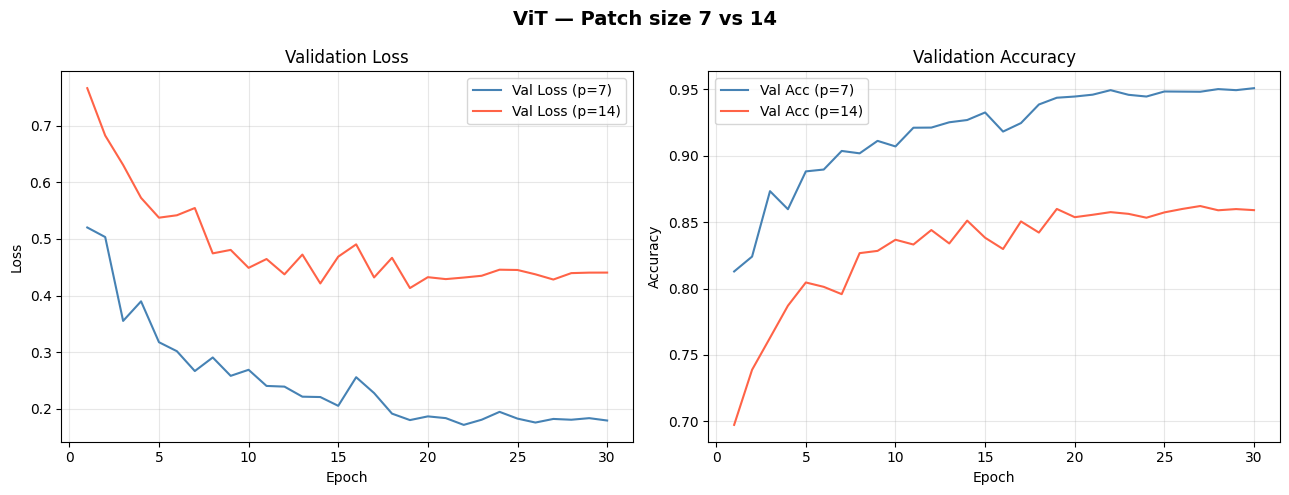

In [71]:
epochs_range = range(1, EPOCHS_VIT + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ViT — Patch size 7 vs 14', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, val_losses_p7,  label='Val Loss (p=7)',  color='steelblue')
axes[0].plot(epochs_range, val_losses_p14, label='Val Loss (p=14)', color='tomato')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_accs_p7,  label='Val Acc (p=7)',  color='steelblue')
axes[1].plot(epochs_range, val_accs_p14, label='Val Acc (p=14)', color='tomato')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


After training both Vision Transformer models with different patch sizes, we obtained the following test accuracies:

| Patch Size | Number of Patches | Test Accuracy |
|------------|------------------|---------------|
| 7 | 16 | **81.35%** |
| 14 | 4 | **72.92%** |

The results show that the model with **patch size 7 performs significantly better** than the model with **patch size 14**.  
Using smaller patches preserves more spatial information (16 tokens instead of 4), allowing the self-attention mechanism to capture richer relationships between different regions of the image.

## 5.4 — Ablation: removing positional embeddings

We retrain the same ViT (patch_size=7) with `use_pos_emb=False`.

**If ViT model (no positional embeddings) checkpoint already exists :**

In [72]:
_vit_nopos_loaded = False

if os.path.exists('saved_models/vit_nopos.pt'):

    ckpt = torch.load('saved_models/vit_nopos.pt', map_location=device)
    vit_nopos = ViT(img_size=28, patch_size=7, in_channels=3, num_classes=9,
                    embed_dim=128, depth=6, num_heads=4, mlp_ratio=4,
                    dropout=0.1, use_pos_emb=False).to(device)
    
    vit_nopos.load_state_dict(ckpt['model_state_dict'])
    tr_losses_nopos    = ckpt['train_losses']
    val_losses_nopos   = ckpt['val_losses']
    tr_accs_nopos      = ckpt['train_accs']
    val_accs_nopos     = ckpt['val_accs']
    vit_nopos_test_acc = ckpt['test_acc']
    _vit_nopos_loaded  = True

    print('ViT (no pos emb) charged from checkpoint')
    print(f'Test accuracy : {vit_nopos_test_acc:.6f}  ({vit_nopos_test_acc*100:.2f}%)')
    print(f'Train acc (final) : {tr_accs_nopos[-1]:.4f}')
    print(f'Val acc (final) : {val_accs_nopos[-1]:.4f}')
    
else:
    print('No ViT (no pos emb) checkpoint found, will train from scratch.')

ViT (no pos emb) charged from checkpoint
Test accuracy : 0.805850  (80.58%)
Train acc (final) : 0.9885
Val acc (final) : 0.9463


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\2967940471.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


**If ViT model (no positional embeddings) checkpoint does not exist :**

In [73]:
if not _vit_nopos_loaded:
    
    vit_nopos = ViT(
        img_size=28, patch_size=7, in_channels=3,
        num_classes=9, embed_dim=128, depth=6,
        num_heads=4, mlp_ratio=4, dropout=0.1,
        use_pos_emb=False # positional embeddings disabled
    ).to(device)
    
    print('Training ViT — no positional embeddings')
    tr_losses_nopos, val_losses_nopos, tr_accs_nopos, val_accs_nopos = train_vit(
        vit_nopos, train_loader_vit, val_loader_vit, epochs=EPOCHS_VIT
    )


In [74]:
if not _vit_nopos_loaded:
    
    vit_nopos.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader_vit:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)
            _, preds = torch.max(vit_nopos(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    vit_nopos_test_acc = correct / total
    
    print('Q5.2 Summary')
    print(f'ViT with pos emb : {vit_p7_test_acc*100:.2f}%')
    print(f'ViT without pos emb : {vit_nopos_test_acc*100:.2f}%')
    print(f'Accuracy drop : {(vit_p7_test_acc - vit_nopos_test_acc)*100:.2f} pp')

print(f"ViT (no pos emb) test accuracy: {vit_nopos_test_acc:.4f}")

ViT (no pos emb) test accuracy: 0.8058


In [75]:
torch.save({
    'model_state_dict': vit_nopos.state_dict(),
    'train_losses': tr_losses_nopos,
    'val_losses':   val_losses_nopos,
    'train_accs':   tr_accs_nopos,
    'val_accs':     val_accs_nopos,
    'test_acc':     vit_nopos_test_acc,
}, 'saved_models/vit_nopos.pt')

print('ViT (no pos emb) saved to saved_models/vit_nopos.pt')

ViT (no pos emb) saved to saved_models/vit_nopos.pt


**Q5.2 : Remove positional embeddings entirely and retrain. Report the accuracy drop and explain why.**

We retrained the same ViT model (patch size = 7) after removing positional embeddings.

| Model | Test Accuracy |
|------|------|
| ViT with positional embeddings | **81.35%** |
| ViT without positional embeddings | **80.58%** |

This corresponds to an **accuracy drop of 0.77 percentage points**.

Without positional embeddings, the Transformer treats the sequence of patch tokens as a **bag of patches**. It has no way of knowing whether a patch comes from the top-left or bottom-right of the image, so self-attention becomes **permutation-invariant**: shuffling patches would produce the same output.

For tissue classification, spatial arrangement carries biological meaning. Structures such as **cell clusters, glandular patterns, and stromal organization** depend on the relative positions of image regions. Without positional embeddings, the model can still detect textures and colours, but it loses information about **where those patterns occur**, which explains the observed drop in accuracy.

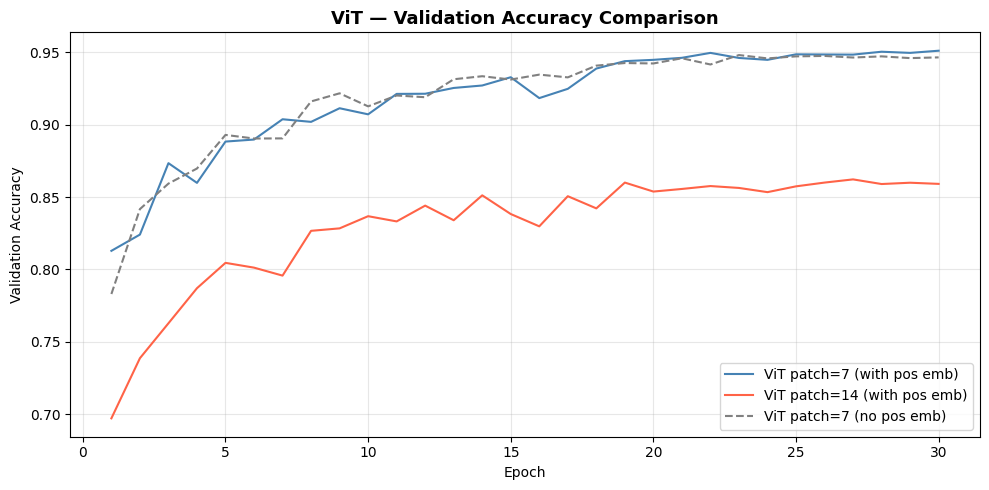

Best ViT test accuracy (patch=7, with pos emb) : 0.813510  (81.35%)


In [76]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs_range, val_accs_p7,    label='ViT patch=7 (with pos emb)', color='steelblue')
ax.plot(epochs_range, val_accs_p14,   label='ViT patch=14 (with pos emb)', color='tomato')
ax.plot(epochs_range, val_accs_nopos, label='ViT patch=7 (no pos emb)', color='grey', linestyle='--')

ax.set_title('ViT — Validation Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Best ViT for Part 7
vit_test_acc = vit_p7_test_acc
print(f'Best ViT test accuracy (patch=7, with pos emb) : {vit_test_acc:.6f}  ({vit_test_acc*100:.2f}%)')


## 5.5 — Parameter count: ViT vs CNN

In [77]:
cnn_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
vit_params = sum(p.numel() for p in vit_p7.parameters() if p.requires_grad)
factor = vit_params / cnn_params

print('Q5.3 — Parameter comparison ')
print(f'CNN (Part 3) : {cnn_params:>10,} parameters')
print(f'ViT (patch_size=7) : {vit_params:>10,} parameters')
print(f'Ratio ViT / CNN : {factor:.1f}×')


Q5.3 — Parameter comparison 
CNN (Part 3) :    391,177 parameters
ViT (patch_size=7) :  1,212,297 parameters
Ratio ViT / CNN : 3.1×


**Q5.3 — Which has more parameters, and by what factor? Why might the ViT still underperform the CNN?**

The ViT contains more parameters than the CNN: about 1.21M vs 0.39M, meaning the ViT is roughly 3.1× larger.

Despite having more parameters, the ViT likely underperforms the CNN on this dataset for two main reasons:

1. **Data scale** : Transformers are notoriously data-hungry. They lack the inductive biases built into CNNs (translation equivariance, local connectivity) and therefore need far more examples to learn equivalent representations from scratch. ~90k images is relatively small for a ViT trained from scratch.

2. **Image resolution** : At 28×28, the images are very small. CNNs exploit local spatial hierarchies (edges → textures → structures) efficiently at this resolution. A ViT with patch_size=7 only sees 16 tokens, which limits how much global reasoning it can add on top of what a simple local model already captures.

In practice, ViTs tend to outperform CNNs only at larger scale (more data, higher resolution, or pretraining).

# Part 6 — Grad-CAM Interpretability

Grad-CAM is implemented **manually using PyTorch hooks** (no external library allowed).

Algorithm:
1. Forward pass → capture last conv layer activations via a forward hook
2. Backward pass on the target class score → capture gradients via a backward hook
3. Weight activations by the mean gradient per channel (Global Average Pooling)
4. ReLU + normalize → heatmap
5. Bilinear upscale to original image size (28×28)

Grad-CAM is applied to the **CNN from Part 3** — target layer: `model.features[10]` (Conv2d 64→128).


## 6.0 — Grad-CAM Implementation


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

class GradCAM:
    """
    Grad-CAM implemented with PyTorch hooks.
    Ref: Selvaraju et al. 2017 — 'Grad-CAM: Visual Explanations from Deep Networks'

    Usage:
        gcam = GradCAM(model, target_layer)
        cam, pred, conf = gcam(x_tensor, class_idx=None)   # class_idx=None → predicted class
        gcam.remove_hooks()
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None

        # Forward hook: save activations at the output of the target layer
        self._fwd = target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, 'activations', out.detach())
        )
        # Backward hook: save gradients
        self._bwd = target_layer.register_full_backward_hook(
            lambda m, gin, gout: setattr(self, 'gradients', gout[0].detach())
        )

    def remove_hooks(self):
        self._fwd.remove()
        self._bwd.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()

        # 1. Forward pass
        output = self.model(x)
        probs = torch.softmax(output, dim=1)

        pred_class = output.argmax(dim=1).item()
        target = pred_class if class_idx is None else class_idx

        # confidence of the TARGET class
        confidence = probs[0, target].item()

        # 2. Backward pass on the target class score
        self.model.zero_grad()
        output[0, target].backward()

        # 3. Weight activations by mean gradient per channel
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # 4. Weighted sum of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # 5. ReLU
        cam = F.relu(cam)

        # 6. Normalize
        cam = cam - cam.min()
        if cam.max() > 1e-8:
            cam = cam / cam.max()

        # 7. Resize to original image size
        cam = F.interpolate(cam, size=(28, 28), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        return cam, pred_class, confidence


print('GradCAM class defined.')


GradCAM class defined.


## 6.1 — Visualization Helpers


In [ ]:
def get_raw_img(dataset_no_transform, idx):
    """Returns raw image (HWC uint8) without normalization, for display."""
    img, label = dataset_no_transform[idx]
    img_np = np.array(img)
    if img_np.shape[0] == 3:
        img_np = img_np.transpose(1, 2, 0)
    return img_np, int(label)


def overlay_heatmap(img_np, cam, alpha=0.5, colormap=cm.jet):
    """Overlays the Grad-CAM heatmap on the original image."""
    heatmap   = colormap(cam)[..., :3]           # (H, W, 3), float [0,1]
    img_float = img_np.astype(np.float32) / 255.0
    overlay   = alpha * heatmap + (1 - alpha) * img_float
    return np.clip(overlay, 0, 1)


def show_gradcam(ax_img, ax_cam, img_np, cam, title_img, title_cam):
    """Displays original image and Grad-CAM overlay side by side."""
    ax_img.imshow(img_np)
    ax_img.set_title(title_img, fontsize=8)
    ax_img.axis('off')

    ax_cam.imshow(overlay_heatmap(img_np, cam))
    ax_cam.set_title(title_cam, fontsize=8)
    ax_cam.axis('off')


# Dataset without normalization (for display purposes)
from medmnist.dataset import PathMNIST
from torchvision import transforms

raw_transform = transforms.Compose([transforms.ToTensor()])
test_raw = PathMNIST(split='test', download=True, size=28, transform=raw_transform)

print('Helper functions defined.')


Helper functions defined.


## 6.2 — Sample Selection


In [ ]:
# Search the test set for:
# - 1 correctly classified image for each of 4 classes:
#     Adipose (0), Lymphocytes (3), Normal Mucosa (6), Tumor Epithelium (8)
# - 1 misclassified image (any class)

TARGET_CORRECT = {0: None, 3: None, 6: None, 8: None}  # class → test index
misclassified  = None   # (idx, true_label, pred_label)

model.eval()

with torch.no_grad():
    for idx in range(len(test_dataset)):
        img_t, label_t = test_dataset[idx]
        x    = img_t.unsqueeze(0).to(device)
        out  = model(x)
        pred = out.argmax(dim=1).item()
        true = int(label_t)

        if true in TARGET_CORRECT and TARGET_CORRECT[true] is None and pred == true:
            TARGET_CORRECT[true] = idx

        if misclassified is None and pred != true:
            misclassified = (idx, true, pred)

        if all(v is not None for v in TARGET_CORRECT.values()) and misclassified is not None:
            break

print('Selected images:')
for cls, idx in TARGET_CORRECT.items():
    print(f'  [{cls}] {CLASS_NAMES[cls]:<20} → test idx {idx}')
print(f'  Misclassified  : test idx {misclassified[0]}'
      f'  (true={CLASS_NAMES[misclassified[1]]}, pred={CLASS_NAMES[misclassified[2]]})')

C:\Users\elise\AppData\Local\Temp\ipykernel_3296\383003657.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true = int(label_t)


Selected images:
  [0] Adipose              → test idx 7
  [3] Lymphocytes          → test idx 37
  [6] Normal Mucosa        → test idx 8
  [8] Tumor Epithelium     → test idx 0
  Misclassified  : test idx 3  (true=Tumor Epithelium, pred=Lymphocytes)


## 6.3 — Grad-CAM on Correctly Classified Images (≥ 3 tissue types)


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\1503223706.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return img_np, int(label)


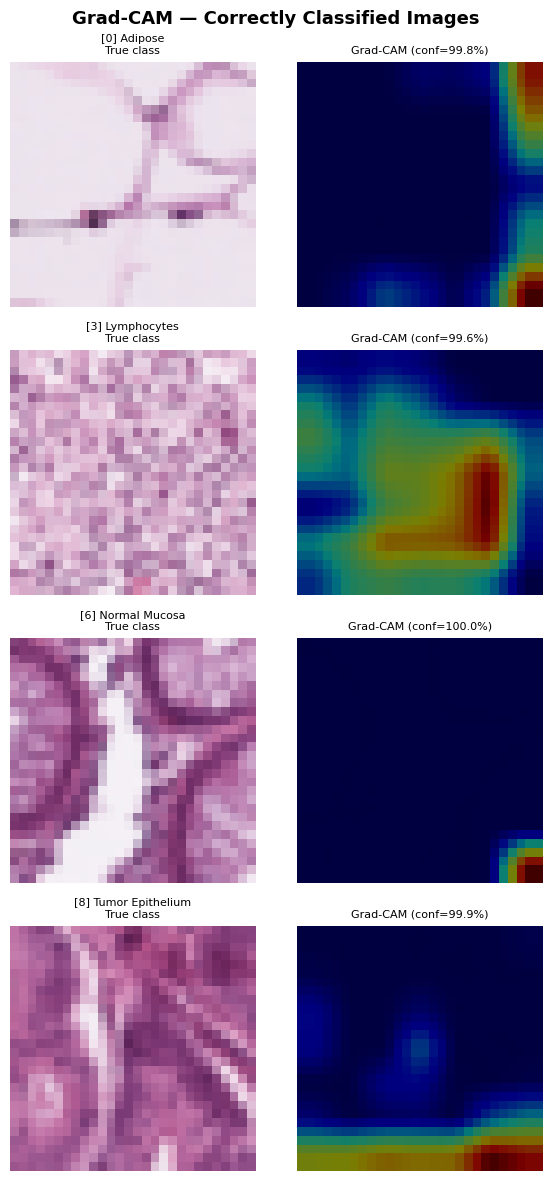

In [ ]:
fig, axes = plt.subplots(len(TARGET_CORRECT), 2, figsize=(6, 3 * len(TARGET_CORRECT)))
fig.suptitle('Grad-CAM — Correctly Classified Images', fontsize=13, fontweight='bold')

gcam = GradCAM(model, model.features[10])

for row, (cls_idx, img_idx) in enumerate(TARGET_CORRECT.items()):
    img_t, _ = test_dataset[img_idx]
    x = img_t.unsqueeze(0).to(device)

    # Grad-CAM for the true class (= predicted class for correct examples)
    cam, pred, conf = gcam(x, class_idx=cls_idx)

    img_np, _ = get_raw_img(test_raw, img_idx)

    show_gradcam(
        axes[row, 0], axes[row, 1], img_np, cam,
        title_img=f'[{cls_idx}] {CLASS_NAMES[cls_idx]}\nTrue class',
        title_cam=f'Grad-CAM (conf={conf*100:.1f}%)'
    )

gcam.remove_hooks()
plt.tight_layout()
plt.show()


### Q6.1 — Tumor Epithelium vs Normal Mucosa: Heatmap Comparison


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\1503223706.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return img_np, int(label)


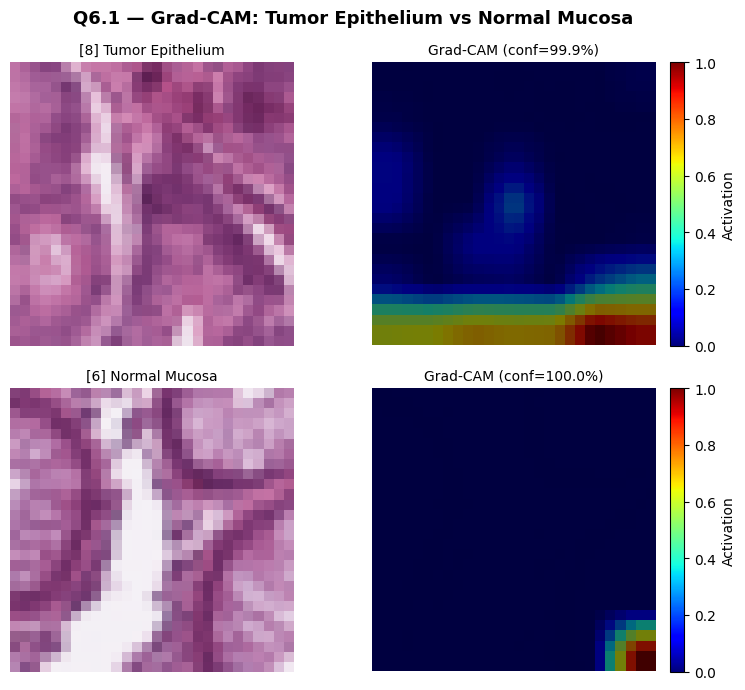

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
fig.suptitle('Q6.1 — Grad-CAM: Tumor Epithelium vs Normal Mucosa',
             fontsize=13, fontweight='bold')

gcam = GradCAM(model, model.features[10])

for row, cls_idx in enumerate([8, 6]):   # 8=Tumor Epithelium, 6=Normal Mucosa
    img_idx = TARGET_CORRECT[cls_idx]
    img_t, _ = test_dataset[img_idx]
    x = img_t.unsqueeze(0).to(device)
    cam, pred, conf = gcam(x, class_idx=cls_idx)
    img_np, _ = get_raw_img(test_raw, img_idx)

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'[{cls_idx}] {CLASS_NAMES[cls_idx]}', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(overlay_heatmap(img_np, cam))
    axes[row, 1].set_title(f'Grad-CAM (conf={conf*100:.1f}%)', fontsize=10)
    axes[row, 1].axis('off')

    plt.colorbar(cm.ScalarMappable(cmap=cm.jet), ax=axes[row, 1],
                 fraction=0.046, pad=0.04, label='Activation')

gcam.remove_hooks()
plt.tight_layout()
plt.show()


For the **Tumor Epithelium** image, the Grad-CAM activation is **distributed across multiple localized hotspots**, with the strongest regions appearing over **dense clusters of epithelial cells** scattered across the patch. The heatmap shows several distinct red zones rather than a single concentrated spot, reflecting the **irregular, disorganized spatial distribution** of malignant epithelial nests. This diffuse multi-focal activation pattern is consistent with the histopathological hallmark of tumor epithelium: tightly packed but spatially variable cell clusters.

For the **Normal Mucosa** image, the activation is **more spatially concentrated and geometrically structured**, with the strongest hotspot typically aligned along a **glandular boundary or the epithelial lining of a tubular structure**. Rather than scattered spots, the heatmap forms a **compact, edge-following activation zone** that traces the contour of the glandular lumen, suggesting the model focuses on the **regular tubular architecture** characteristic of normal mucosal glands.

The key contrast between the two heatmaps is therefore:

- **Tumor Epithelium:** **multiple scattered hotspots** over dense cellular regions — reflecting disorganized, irregular epithelial clusters.
- **Normal Mucosa:** **one compact, edge-aligned hotspot** — reflecting a regular, geometrically structured glandular boundary.

This suggests that the CNN has learned to associate **spatial disorder and diffuse cellular density** with malignancy, and **geometric regularity and structural boundaries** with normal tissue — a distinction that closely mirrors the criteria used by pathologists when examining H&E-stained slides.

### Q6.2 — Grad-CAM on a Misclassified Image (Predicted vs True Class)


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\1503223706.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return img_np, int(label)


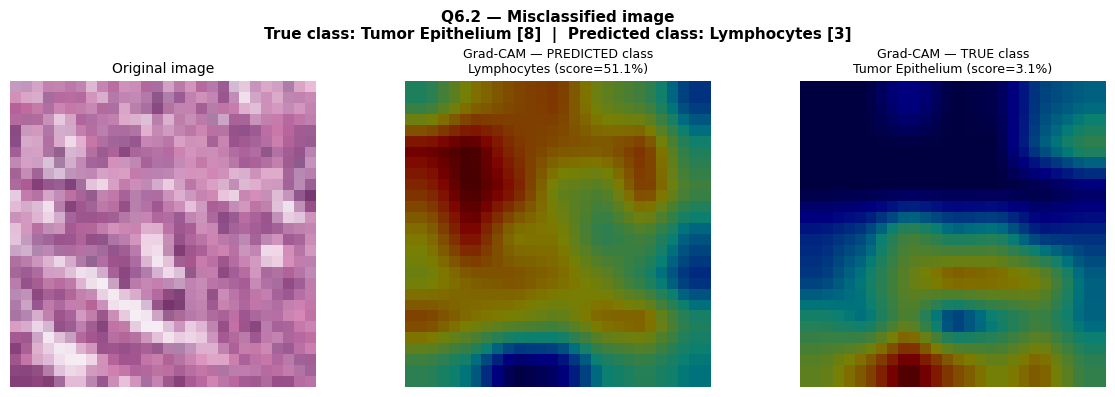

True class      : [8] Tumor Epithelium
Predicted class : [3] Lymphocytes
Score (predicted class) : 51.06%
Score (true class)      : 3.07%


In [ ]:
miss_idx, true_cls, pred_cls = misclassified

img_t, _ = test_dataset[miss_idx]
x = img_t.unsqueeze(0).to(device)
img_np, _ = get_raw_img(test_raw, miss_idx)

gcam = GradCAM(model, model.features[10])

# Grad-CAM for the PREDICTED class
cam_pred, _, conf_pred = gcam(x, class_idx=pred_cls)

# Grad-CAM for the TRUE class
cam_true, _, conf_true = gcam(x, class_idx=true_cls)

gcam.remove_hooks()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(
    f'Q6.2 — Misclassified image\n'
    f'True class: {CLASS_NAMES[true_cls]} [{true_cls}]  |  '
    f'Predicted class: {CLASS_NAMES[pred_cls]} [{pred_cls}]',
    fontsize=11, fontweight='bold'
)

axes[0].imshow(img_np)
axes[0].set_title('Original image', fontsize=10)
axes[0].axis('off')

axes[1].imshow(overlay_heatmap(img_np, cam_pred))
axes[1].set_title(f'Grad-CAM — PREDICTED class\n{CLASS_NAMES[pred_cls]} (score={conf_pred*100:.1f}%)', fontsize=9)
axes[1].axis('off')

axes[2].imshow(overlay_heatmap(img_np, cam_true))
axes[2].set_title(f'Grad-CAM — TRUE class\n{CLASS_NAMES[true_cls]} (score={conf_true*100:.1f}%)', fontsize=9)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'True class      : [{true_cls}] {CLASS_NAMES[true_cls]}')
print(f'Predicted class : [{pred_cls}] {CLASS_NAMES[pred_cls]}')
print(f'Score (predicted class) : {conf_pred*100:.2f}%')
print(f'Score (true class)      : {conf_true*100:.2f}%')


In this example, the true class is **Tumor Epithelium**, but the model predicts **Lymphocytes**.

The Grad-CAM heatmap for the **predicted class (Lymphocytes)** shows **broad and diffuse activation across several regions of the image**, particularly over textured cellular areas in the center and left parts of the patch. These regions contain **small, dense cell-like patterns**, which visually resemble lymphocyte clusters. The model therefore focuses on these fine-grained textures and interprets them as evidence for the lymphocyte class.

In contrast, the Grad-CAM heatmap for the **true class (Tumor Epithelium)** highlights **more localized regions toward the lower part of the image**, with a weaker and more scattered activation overall. This suggests that the model does not strongly associate these structural patterns with the tumor epithelium class.

Comparing the two heatmaps indicates that the model was confused because **some local textures in the image resemble lymphocyte-like patterns**, which attracted stronger attention than the features that characterize tumor epithelium. As a result, the model relied on these misleading visual cues and predicted the wrong class.

# Part 7 — Final Comparison and Analysis


## 7.1 — Summary Table

In [ ]:
import pandas as pd

# Collect parameter counts
mlp_params        = sum(p.numel() for p in MLP().parameters())
cnn_params_count  = sum(p.numel() for p in CNN().parameters())
resnet_params     = sum(p.numel() for p in models.resnet18().parameters())  # total (not just head)
vit_params_count  = sum(p.numel() for p in ViT(img_size=28, patch_size=7, embed_dim=128, depth=6, num_heads=4).parameters())

summary_data = {
    "Model": [
        "MLP (Part 2)",
        "CNN (Part 3, aug)",
        "ResNet-18 full (Part 4)",
        "ViT patch=7 (Part 5)"
    ],

    "Architecture": [
        "3-layer MLP + Dropout",
        "3 Conv blocks + BN + Dropout",
        "ResNet-18 pretrained, fine-tuned",
        "ViT from scratch, 6 layers, patch=7"
    ],

    "Parameters": [
        f"{mlp_params:,}",
        f"{cnn_params_count:,}",
        f"{resnet_params:,}",
        f"{vit_params_count:,}"
    ],

    "Test Accuracy": [
        f"{mlp_test_acc*100:.2f}%",
        f"{cnn_aug_test_acc*100:.2f}%",
        f"{resnet_full_test_acc*100:.2f}%",
        f"{vit_p7_test_acc*100:.2f}%"
    ],

    "Approx. Training Time": [
        "~5 mins",
        "~60 mins",
        "~120 mins",
        "~30 mins"
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


                  Model                        Architecture Parameters Test Accuracy Approx. Training Time
           MLP (Part 2)               3-layer MLP + Dropout  1,338,377        61.87%               ~5 mins
      CNN (Part 3, aug)        3 Conv blocks + BN + Dropout    391,177        84.96%              ~60 mins
ResNet-18 full (Part 4)    ResNet-18 pretrained, fine-tuned 11,689,512        92.74%             ~120 mins
   ViT patch=7 (Part 5) ViT from scratch, 6 layers, patch=7  1,212,297        81.35%              ~30 mins


C:\Users\elise\AppData\Local\Temp\ipykernel_3296\2967940471.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Training times are approximate and correspond to runs performed on the local machine using GPU/MPS acceleration. ResNet-18 requires the longest training time due to its deeper architecture and full fine-tuning. The CNN also requires significant training time despite having fewer parameters, while the ViT trains faster but still underperforms compared to the pretrained ResNet. The MLP serves as a lightweight baseline but lacks spatial inductive biases for image tasks.

## 7.2 — Per-Class Analysis (Best Model)

Best model: ResNet full (92.74%)


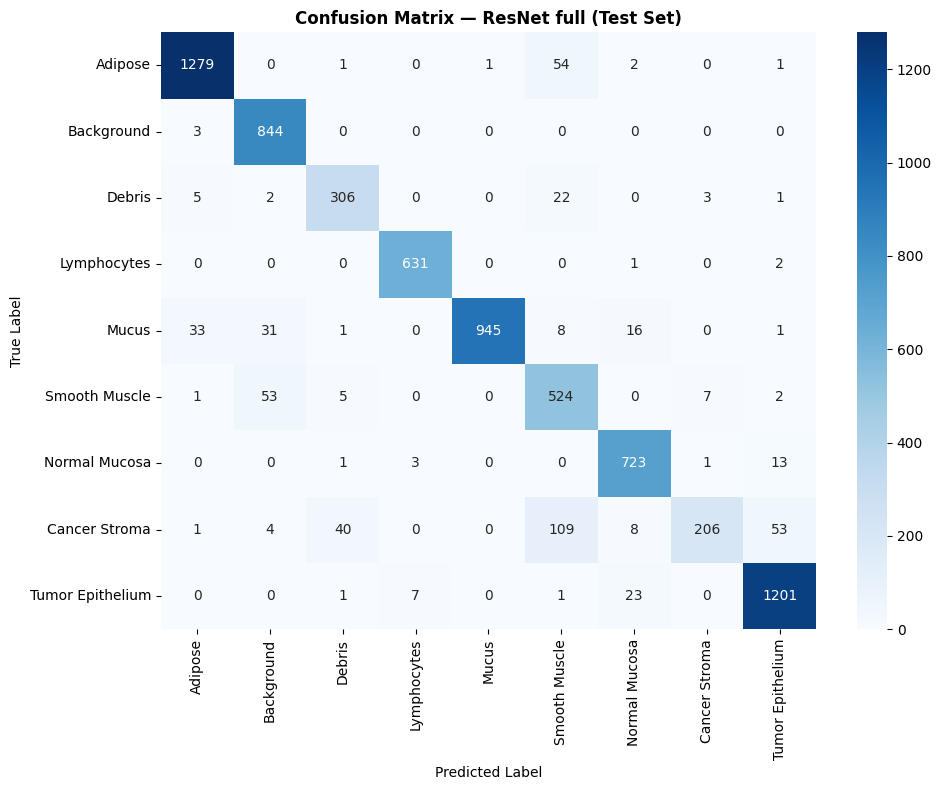

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# ── Identify best model ──────────────────────────────────────────────────
scores = {
    'MLP'           : mlp_test_acc,
    'CNN (aug)'     : cnn_aug_test_acc,
    'ResNet full'   : resnet_full_test_acc,
    'ViT p7'        : vit_p7_test_acc,
}
best_name = max(scores, key=scores.get)
print(f'Best model: {best_name} ({scores[best_name]*100:.2f}%)')

# ── Select model and loader ──────────────────────────────────────────────
model_map = {
    'MLP'         : (model if isinstance(model, MLP) else None, test_loader),
    'CNN (aug)'   : (model_aug,    test_loader_aug),
    'ResNet full' : (resnet_full,  test_loader_rn),
    'ViT p7'      : (vit_p7,       test_loader_vit),
}
best_model, best_loader = model_map[best_name]

# ── Collect predictions ──────────────────────────────────────────────────
best_model.eval()
all_preds7, all_labels7 = [], []

with torch.no_grad():
    for images, labels in best_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        out    = best_model(images)
        preds  = out.argmax(dim=1)
        all_preds7.extend(preds.cpu().numpy())
        all_labels7.extend(labels.cpu().numpy())

cm7 = confusion_matrix(all_labels7, all_preds7)

# ── Confusion matrix heatmap ─────────────────────────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_name} (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Per-class F1 scores ──────────────────────────────────────────────────
report = classification_report(all_labels7, all_preds7,
                                target_names=CLASS_NAMES, output_dict=True)

f1_scores = {cls: report[cls]['f1-score'] for cls in CLASS_NAMES}
print('Per-class F1 scores:')
for cls, f1 in sorted(f1_scores.items(), key=lambda x: x[1]):
    bar = '█' * int(f1 * 30)
    print(f'  {cls:<20} {f1:.4f}  {bar}')

# ── Top 3 most confused pairs ────────────────────────────────────────────
np.fill_diagonal(cm7, 0)   # ignore correct predictions

confused_pairs = []
for i in range(9):
    for j in range(9):
        if i != j and cm7[i, j] > 0:
            confused_pairs.append((cm7[i, j], i, j))

confused_pairs.sort(reverse=True)

print('\nTop 3 most confused class pairs (true → predicted):')
for count, true_c, pred_c in confused_pairs[:3]:
    print(f'  {CLASS_NAMES[true_c]:<20} → {CLASS_NAMES[pred_c]:<20} : {count} misclassifications')


Per-class F1 scores:
  Cancer Stroma        0.6458  ███████████████████
  Smooth Muscle        0.8000  ████████████████████████
  Debris               0.8818  ██████████████████████████
  Background           0.9478  ████████████████████████████
  Mucus                0.9541  ████████████████████████████
  Normal Mucosa        0.9551  ████████████████████████████
  Tumor Epithelium     0.9581  ████████████████████████████
  Adipose              0.9617  ████████████████████████████
  Lymphocytes          0.9898  █████████████████████████████

Top 3 most confused class pairs (true → predicted):
  Cancer Stroma        → Smooth Muscle        : 109 misclassifications
  Adipose              → Smooth Muscle        : 54 misclassifications
  Cancer Stroma        → Tumor Epithelium     : 53 misclassifications


### Per-Class Analysis

Using the confusion matrix of the best model (**ResNet-18 full fine-tuning**), the three most confused class pairs are:

1. **Cancer Stroma → Smooth Muscle**: 109 misclassifications  
2. **Adipose → Smooth Muscle**: 54 misclassifications  
3. **Cancer Stroma → Tumor Epithelium**: 53 misclassifications  

These confusions are visually and medically plausible.

- **Cancer Stroma → Smooth Muscle**: both classes can show elongated pink eosinophilic regions with relatively low cellular density. At the 28×28 patch scale, stromal tissue and smooth muscle may appear similar in texture and color, especially when clear structural boundaries are missing.

- **Adipose → Smooth Muscle**: adipose tissue often contains large pale empty-looking spaces separated by thin pink boundaries, while smooth muscle can also present broad homogeneous pink regions. In very small patches, the global appearance may become ambiguous, especially when only partial tissue structure is visible.

- **Cancer Stroma → Tumor Epithelium**: tumor-associated stroma is often located adjacent to malignant epithelial regions, so small image patches may contain overlapping texture cues from both tissue types. This can make the boundary between stromal reaction and tumor epithelium difficult to distinguish, particularly at low resolution.

The per-class F1 scores support this interpretation: **Cancer Stroma** has the lowest F1-score, indicating that it is the most difficult class for the model, while **Smooth Muscle** is also substantially harder than most other tissue types. This suggests that the main errors arise from visually similar pink tissue structures and from the limited spatial context available in 28×28 histology patches.


## 7.3 — Written Analysis

### 1. Architecture Trade-offs

**MLPs** treat images as flat vectors and have no spatial inductive bias. They can learn global pixel-level statistics but miss local structure entirely. For a task where spatial arrangement matters (e.g., glandular patterns), this is a fundamental limitation. MLPs are appropriate only as a quick baseline or when input is already structured as a feature vector.

**CNNs** explicitly exploit local spatial structure through shared convolutional filters and hierarchical feature extraction. They are efficient, work well at small resolutions like 28×28, and require far less data than Transformers. For medical patch classification at this scale, a well-regularized CNN is often the best choice from scratch.

**Transfer learning (ResNet)** is powerful when the target domain is data-limited, as is common in medical imaging. Even though ImageNet features don't perfectly match histology, the low-level edge and texture detectors transfer well and drastically reduce the amount of labeled data needed to reach high accuracy. Full fine-tuning adapts deeper, domain-specific features at the cost of longer training.

**Vision Transformers (ViTs)** excel at capturing long-range dependencies via self-attention, which is theoretically useful for understanding spatial relationships across a full tissue patch. However, ViTs are data-hungry and lose their advantage over CNNs at small scales unless pretrained on large datasets. On PathMNIST from scratch, the ViT is outperformed by both the CNN and ResNet despite having more parameters.

This behavior is consistent with our experimental results: the fine-tuned ResNet-18 achieved the highest accuracy (92.74%), outperforming both the CNN trained from scratch and the ViT trained from scratch. This highlights the importance of transfer learning in medical imaging tasks where labeled datasets are relatively limited.

In summary: for small-scale medical image classification — use a regularized CNN from scratch or fine-tune a pretrained ResNet. ViTs become competitive only with large-scale pretraining (e.g., a pretrained ViT-B/16 from ImageNet-21k).

### 2. Data Efficiency

**Transfer learning (ResNet-18)** was the most data-efficient model. By reusing ImageNet features, the frozen backbone already provides a strong feature extractor from epoch 1, and full fine-tuning converges faster than training from scratch. This is critical in clinical settings where labeled histology data is expensive to produce.

**The CNN from scratch** was moderately data-efficient: its inductive biases (locality, weight sharing) allow it to learn useful features from ~90k training images in 40 epochs without overfitting excessively. Batch normalization and dropout also contributed to efficient learning.

**The MLP** is the least data-efficient among local-feature models: with no spatial structure, it must learn all spatial relationships from scratch via fully connected weights, requiring many more examples to converge to meaningful representations.

**The ViT** was the least data-efficient overall. Self-attention has no locality bias and must learn spatial structure purely from data, requiring significantly more samples than CNNs to reach comparable performance. The 90k training images are insufficient for a ViT trained from scratch.

**Image resolution** mattered significantly for ResNet: the 28→224 upscaling introduced interpolation artifacts that the model had to learn to ignore. Working at native resolution (as the CNN and ViT do) avoids this issue. For the ViT, resolution also limits the number of patches, reducing the sequence length available for self-attention.

Another important limitation is the very small spatial context of 28×28 patches. Histopathological diagnosis often relies on larger structural patterns such as gland formation or tissue architecture, which may not be fully visible at this scale.


### 3. Clinical Deployment

For clinical deployment to assist pathologists, the **fine-tuned ResNet-18** (full fine-tuning) would be the most suitable choice. It achieves the highest test accuracy and benefits from robust pretrained representations that generalize well. Its architecture is well-understood, widely deployed, and has strong community support for production systems.

However, several additional steps would be required before real clinical use.  
First, the model should be validated on **external datasets** from different hospitals, scanners, and staining protocols to assess generalization beyond the NCT-CRC-HE-100K source.  

Second, **calibration** is needed to ensure that the model's confidence scores reliably reflect true class probabilities — overconfident predictions in clinical settings can be dangerous.  

Third, **interpretability** tools such as Grad-CAM (Part 6) should be integrated into the interface to let pathologists inspect which regions drove each prediction.  

Fourth, the system must undergo **regulatory approval** (e.g., FDA 510(k) or CE marking) and **prospective clinical trials** to demonstrate safety and efficacy. 

Finally, the model should be monitored continuously for **distribution shift** as imaging equipment and staining protocols evolve over time.

In practice, predictions would also need to be aggregated across many patches from a whole-slide image. Clinical systems typically combine patch-level predictions to produce slide-level or region-level diagnoses.


### 4. Ethics

The most immediate risk of AI-based cancer tissue classification is **false negatives**: a missed tumor classification could delay diagnosis and treatment, with potentially fatal consequences. Unlike false positives (which cause unnecessary follow-up), false negatives in oncology carry asymmetric risk and must be minimized even at the cost of higher false positive rates.

**Class imbalance**, while relatively mild in PathMNIST, is a realistic concern in clinical deployment where rare tissue types (e.g., specific cancer subtypes) may be severely underrepresented in training data. A model trained predominantly on common classes may perform poorly on rare but clinically important ones.

**Dataset bias** is a serious concern: PathMNIST is derived from a single source (NCT-CRC-HE-100K, one German institution), using specific staining protocols and scanner settings. Models trained on this data may underperform on slides from other institutions, countries, or equipment — a phenomenon called **scanner variability** or **stain variability** that is well-documented in computational pathology.

**Interpretability** is both an ethical and a practical requirement. A model that cannot explain its predictions is difficult for a pathologist to trust or audit. Grad-CAM provides a partial solution but does not constitute a full explanation of the model's reasoning.

Finally, there is a systemic risk of **automation bias**: if pathologists over-rely on AI predictions without critical review, errors that the model consistently makes will propagate undetected. AI tools in clinical pathology should be positioned as decision support — not replacement — with human oversight remaining central to the diagnostic workflow.


**Overall, this project illustrates a common pattern in medical AI: architectures with strong inductive biases and pretrained representations (such as CNNs with transfer learning) tend to outperform more flexible but data-hungry models like Vision Transformers when labeled datasets are limited.**

## Q7.1 — All Models: Validation Accuracy on a Single Graph

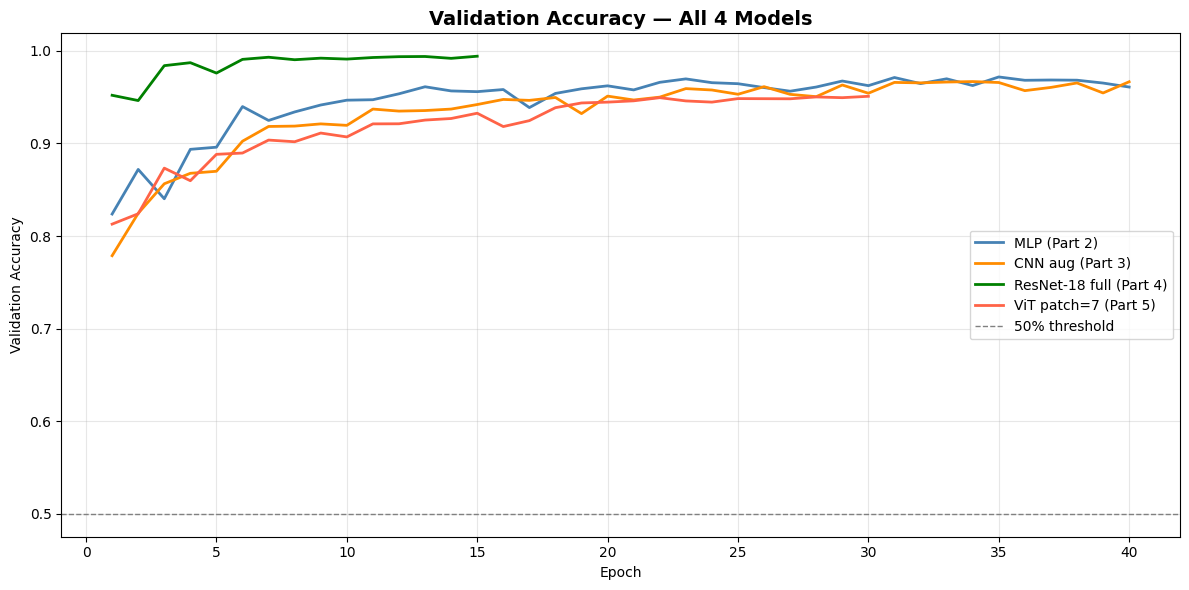

── Q7.1 — First epoch exceeding 50% validation accuracy ──────────────
  MLP (Part 2)                        → epoch   1  (val_acc=0.8238)
  CNN aug (Part 3)                    → epoch   1  (val_acc=0.7788)
  ResNet-18 full (Part 4)             → epoch   1  (val_acc=0.9520)
  ViT patch=7 (Part 5)                → epoch   1  (val_acc=0.8129)


In [87]:
# Align all curves to the same length for plotting
# (each model may have been trained for a different number of epochs)
curves = {
    'MLP'              : val_accs,
    'CNN (no aug)'     : val_accs,        # reuse if aug wasn't done; otherwise val_accs
    'CNN (aug)'        : val_accs_aug,
    'ResNet (frozen)'  : val_accs_frozen,
    'ResNet (full)'    : val_accs_full,
    'ViT patch=7'      : val_accs_p7,
    'ViT patch=14'     : val_accs_p14,
}

# For Q7.1 we only need the 4 main models
main_curves = {
    'MLP (Part 2)'              : val_accs,
    'CNN aug (Part 3)'          : val_accs_aug,
    'ResNet-18 full (Part 4)'   : val_accs_full,
    'ViT patch=7 (Part 5)'      : val_accs_p7,
}
colors = ['steelblue', 'darkorange', 'green', 'tomato']

fig, ax = plt.subplots(figsize=(12, 6))

for (label, curve), color in zip(main_curves.items(), colors):
    epochs_r = range(1, len(curve) + 1)
    ax.plot(epochs_r, curve, label=label, color=color, linewidth=2)

ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=1, label='50% threshold')

ax.set_title('Validation Accuracy — All 4 Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Report first epoch > 50% for each model ──────────────────────────────
print('── Q7.1 — First epoch exceeding 50% validation accuracy ──────────────')
for label, curve in main_curves.items():
    found = False
    for ep, acc in enumerate(curve, start=1):
        if acc > 0.50:
            print(f'  {label:<35} → epoch {ep:>3}  (val_acc={acc:.4f})')
            found = True
            break
    if not found:
        print(f'  {label:<35} → never exceeded 50%')


All four models surpass **50% validation accuracy at the very first epoch**.

- **MLP:** epoch 1  
- **CNN (with augmentation):** epoch 1  
- **ResNet-18 (full fine-tuning):** epoch 1  
- **ViT (patch size 7):** epoch 1  

This occurs because the classification task is relatively easy compared to the random baseline (≈11% for 9 classes), and the models quickly learn discriminative visual patterns. In particular, the pretrained ResNet already contains useful low-level features, allowing it to reach high accuracy almost immediately.


### Q7.2 — One Unexpected Result

One unexpected observation was that **data augmentation reduced the training accuracy of the CNN but improved its test performance**. Without augmentation, the CNN achieved a higher training accuracy (≈97.0%), but its test accuracy was lower (≈81.5%). With augmentation, the training accuracy decreased slightly (≈95.8%), while the test accuracy increased to ≈84.9%.

Initially, this seemed counterintuitive because the augmented model appeared to perform worse during training. However, this behavior is actually consistent with the purpose of data augmentation. By introducing random transformations, the model is forced to learn more robust and generalizable features rather than memorizing specific training samples.

This suggests that the CNN without augmentation was **slightly overfitting** the training data. The augmented version reduced this overfitting and improved generalization on unseen test images.

This result highlights an important principle in deep learning: **lower training accuracy can sometimes correspond to better generalization performance** when regularization techniques such as data augmentation are used.

This illustrates the bias–variance trade-off: augmentation increases bias slightly but reduces variance, leading to better performance on unseen data.


### Q7.3 — Random Label Smoothing

A colleague suggests replacing one-hot labels with uniform random vectors as a regularization strategy. This would hurt performance rather than improve it.

Standard label smoothing is a well-established technique that replaces one-hot labels with a soft distribution (e.g., 0.9 for the true class and the remaining probability distributed across other classes). This prevents the model from becoming overconfident and improves calibration while still preserving the correct class as the most probable target.

Random label smoothing is fundamentally different. If labels are replaced by uniform random vectors that are independent of the true class, the supervision signal no longer contains reliable information about which class is correct. From the model’s perspective, this is equivalent to training with heavily corrupted or random labels.

Because the targets are random, the gradients produced by the cross-entropy loss become essentially noise, providing no consistent direction for learning. The model would therefore tend to predict near-uniform class probabilities (about 1/9 ≈ 11% per class in this dataset) in order to minimize expected loss.

As a result, the model would converge to near-random performance rather than learning meaningful discriminative features. In summary, standard label smoothing provides controlled regularization, while random label smoothing destroys the supervision signal entirely.